# Modele ML pentru explicarea importanței variabilelor

Acest notebook tratează a treia etapă a analizei rezultatelor și are ca scop utilizarea modelelor de Machine Learning pentru identificarea variabilelor care contribuie în cea mai mare măsură la explicarea performanței de interogare în PostgreSQL mononod și PostgreSQL distribuit prin Citus.

Sunt urmărite două direcții principale:

1. Modelarea executabilității interogărilor folosind variabila țintă `success` - urmărește identificarea factorilor care influențează probabilitatea ca o interogare să ruleze cu succes.
   - Regresie logistică (glmnet)
   - Random Forest

Modelele de clasificare răspund la întrebarea: în ce măsură caracteristicile scenariului experimental - arhitectură, număr de workeri, strategie de distribuire, scale factor și structură a interogării  pot explica dacă o execuție de query se finalizează cu succes sau eșuează.

2. Modelarea timpului de execuție cu variabila țintă `duration` (log10(elapsed_sec)) - urmărește care sunt factorii care explică variația timpilor de execuție pentru interogările finalizate cu succes.
   - Regresie liniară
   - Random Forest Regressor

Pentru ambele direcții, analiza include pregătirea datelor, împărțirea în set de antrenare și set de testare, definirea rețetelor de preprocesare, antrenarea modelelor, tuning-ul hiperparametrilor acolo unde este cazul, evaluarea performanței pe setul de test și extragerea importanței variabilelor.

Rezultatele obținute vor fi interpretate în raport cu întrebările de cercetare definite în capitolul de Metodologie, cu accent pe efectul arhitecturii, al numărului de workeri, al strategiei de distribuire și al caracteristicilor de interogare asupra performanței.

In [2]:
options(scipen = 999)
library(tidyverse)
library(tidymodels)
library(scales)
library(patchwork)
library(viridis)
library(ggsci)
library(svglite)
set.seed(123)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'tidyr' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'forcats' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.1
✔ ggplot2   4.0.3     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to 

In [3]:
base_dir <- ".."

df <- file.path(base_dir, "citus_outputs","df_tests.rds")

df <- readRDS(df)

glimpse(df)

Rows: 3,750
Columns: 44
$ scenario            <chr> "SF10_N0", "SF10_N0", "SF10_N0", "SF10_N0", "SF10_…
$ sf                  <dbl> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10…
$ workers             <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ strategy            <fct> baseline, baseline, baseline, baseline, baseline, …
$ architecture        <fct> baseline, baseline, baseline, baseline, baseline, …
$ query_id            <chr> "Q001", "Q002", "Q003", "Q004", "Q005", "Q006", "Q…
$ query_no            <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,…
$ status              <fct> SUCCESS, SUCCESS, SUCCESS, SUCCESS, SUCCESS, SUCCE…
$ success             <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TR…
$ elapsed_sec         <dbl> 14.165, 6.954, 11.010, 12.679, 29.054, 114.241, 1.…
$ n_tables            <dbl> 3, 3, 4, 6, 4, 4, 2, 3, 3, 3, 3, 4, 4, 4, 3, 4, 3,…
$ n_joins             <dbl> 2, 2, 3, 5, 3, 3, 1, 2, 3, 3, 2, 3, 2, 3, 2, 3, 4,…
$ n_inner_joins 

In [4]:
tables_dir <- file.path(base_dir, "citus_outputs", "tables")
figures_dir <- file.path(base_dir, "citus_outputs", "figures")
models_dir <- file.path(base_dir, "citus_outputs", "models")

In [7]:
missing <- sum(is.na(df))

missing

[1] 0

# I. Pregatirea datasetului pentru modelele de clasificare

In [10]:
# Dataset pentru clasificare: variabila target = success

df_classif <- df %>%
  select(
    success,
    sf,
    workers,
    strategy,
    architecture,
    query_id,
    starts_with("n_"),
    starts_with("has_")
  ) %>%
  mutate(
    success = factor(success, levels = c("TRUE", "FALSE")),
    sf = factor(sf),
    workers = factor(workers),
    strategy = factor(strategy),
    architecture = factor(architecture)
  )

glimpse(df_classif)

Rows: 3,750
Columns: 39
$ success             <fct> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TR…
$ sf                  <fct> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10…
$ workers             <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ strategy            <fct> baseline, baseline, baseline, baseline, baseline, …
$ architecture        <fct> baseline, baseline, baseline, baseline, baseline, …
$ query_id            <chr> "Q001", "Q002", "Q003", "Q004", "Q005", "Q006", "Q…
$ n_tables            <dbl> 3, 3, 4, 6, 4, 4, 2, 3, 3, 3, 3, 4, 4, 4, 3, 4, 3,…
$ n_joins             <dbl> 2, 2, 3, 5, 3, 3, 1, 2, 3, 3, 2, 3, 2, 3, 2, 3, 4,…
$ n_inner_joins       <dbl> 2, 2, 3, 5, 2, 3, 1, 2, 3, 3, 2, 3, 2, 3, 2, 3, 4,…
$ n_left_joins        <dbl> 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_right_joins       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_full_joins        <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_cross_joins 

In [11]:
success_distribution <- df_classif %>%
  count(success) %>%
  mutate(
    pct = round(n / sum(n) * 100, 2)
  )

success_distribution

success,n,pct
<fct>,<int>,<dbl>
TRUE,3371,89.89
FALSE,379,10.11


In [12]:
write_csv(
  success_distribution,
  file.path(tables_dir, "03_ml_success_distribution.csv")
)

Distribuția variabilei țintă `success` arată un dezechilibru între clase, deoarece majoritatea execuțiilor sunt finalizate cu succes, iar eșecurile reprezintă o proporție mai redusă din totalul observațiilor. Din acest motiv, evaluarea modelelor nu se va baza exclusiv pe acuratețe, ci va include și metrici precum balanced accuracy, sensitivity, specificity și ROC-AUC.

In [13]:
# Query-level summary for grouped and stratified split

query_split_info <- df_classif %>%
  group_by(query_id) %>%
  summarise(
    has_failure = any(success == "FALSE"),
    n_obs = n(),
    n_failures = sum(success == "FALSE"),
    n_success = sum(success == "TRUE"),
    .groups = "drop"
  ) %>%
  mutate(
    has_failure = factor(has_failure, levels = c(FALSE, TRUE))
  )

query_split_info %>%
  count(has_failure)

has_failure,n
<fct>,<int>
FALSE,204
TRUE,46


## Împărțirea în seturi de train și test

In [14]:
set.seed(123)

query_split <- initial_split(
  query_split_info,
  prop = 0.70,
  strata = has_failure
)

train_query_ids <- training(query_split) %>%
  pull(query_id)

test_query_ids <- testing(query_split) %>%
  pull(query_id)

Împărțirea train/test pentru clasificare a fost realizată la nivel de `query_id`, pentru a evita ca aceeași interogare să apară simultan în setul de antrenare și în cel de testare. Deoarece variabila țintă `success` este dezechilibrată, split-ul a fost stratificat după o variabilă auxiliară, `has_failure`, care indică dacă un query a avut cel puțin o execuție eșuată. Astfel, ambele seturi conțin atât interogări executate cu succes, cât și interogări problematice, reducând riscul de supraestimare a performanței modelului.

In [15]:
training(query_split) %>%
  count(has_failure)

testing(query_split) %>%
  count(has_failure)

has_failure,n
<fct>,<int>
FALSE,142
TRUE,32


has_failure,n
<fct>,<int>
FALSE,62
TRUE,14


In [16]:
classif_train <- df_classif %>%
  filter(query_id %in% train_query_ids)

classif_test <- df_classif %>%
  filter(query_id %in% test_query_ids)

In [17]:
classif_split_distribution <- bind_rows(
  classif_train %>%
    count(success) %>%
    mutate(
      pct = round(n / sum(n) * 100, 2),
      dataset = "train"
    ),
  classif_test %>%
    count(success) %>%
    mutate(
      pct = round(n / sum(n) * 100, 2),
      dataset = "test"
    )
)

classif_split_distribution

success,n,pct,dataset
<fct>,<int>,<dbl>,<chr>
TRUE,2346,89.89,train
FALSE,264,10.11,train
TRUE,1025,89.91,test
FALSE,115,10.09,test


În ambele seturi, aproximativ 90% dintre observații reprezintă execuții reușite, iar aproximativ 10% reprezintă execuții eșuate. Acest rezultat confirmă faptul că împărțirea stratificată pe baza variabilei auxiliare `has_failure` a păstrat reprezentarea cazurilor problematice în ambele seturi.

In [19]:
write_csv(
  classif_split_distribution,
  file.path(tables_dir, "03_ml_classification_train_test_distribution.csv")
)

## Definirea foldurilor pentru validare încrucișată

In [21]:
set.seed(123)

classif_folds <- group_vfold_cv(
  classif_train,
  group = query_id,
  v = 5
)

In [22]:
classif_folds %>%
  select(id)

id
<chr>
Resample1
Resample2
Resample3
Resample4
Resample5


In [23]:
classif_folds_distribution <- classif_folds %>%
  mutate(
    assessment_data = map(splits, assessment)
  ) %>%
  select(id, assessment_data) %>%
  unnest(assessment_data) %>%
  count(id, success) %>%
  group_by(id) %>%
  mutate(
    pct = round(n / sum(n) * 100, 2)
  ) %>%
  ungroup()

classif_folds_distribution

id,success,n,pct
<chr>,<fct>,<int>,<dbl>
Resample1,TRUE,511,97.33
Resample1,FALSE,14,2.67
Resample2,TRUE,490,93.33
Resample2,FALSE,35,6.67
Resample3,TRUE,436,83.05
Resample3,FALSE,89,16.95
Resample4,TRUE,488,92.95
Resample4,FALSE,37,7.05
Resample5,TRUE,421,82.55


Distribuția variabilei `success` a fost verificată și la nivelul fold-urilor de cross-validation. Fiecare fold conține atât execuții reușite, cât și execuții eșuate, ceea ce permite evaluarea modelelor pe ambele clase ale variabilei țintă. Fold-urile au fost create grupat după `query_id`, pentru a evita ca aceeași interogare să apară simultan în partea de antrenare și în partea de validare a aceluiași fold.

In [24]:
write_csv(
  classif_folds_distribution,
  file.path(tables_dir, "03_ml_classification_cv_folds_distribution.csv")
)

## Crearea rețetei
Acest pas include următoarele:
- query_id devinde identificator, nu predictor
- dummyficarea variabilelor nominale
- eliminarea predictorilor cu variannță 0
- standardizarea predictorilor numerici

In [25]:
classif_recipe <- recipe(success ~ ., data = classif_train) %>%
  update_role(query_id, new_role = "id") %>%
  step_dummy(all_nominal_predictors()) %>%
  step_zv(all_predictors()) %>%
  step_normalize(all_numeric_predictors())

classif_recipe



── Recipe ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:    1
predictor: 37
id:         1



── Operations 

• Dummy variables from: all_nominal_predictors()

• Zero variance filter on: all_predictors()

• Centering and scaling for: all_numeric_predictors()



## Metricile pentru clasificare

In [26]:
classif_metrics <- metric_set(
  roc_auc,
  accuracy,
  bal_accuracy,
  sens,
  spec
)

## Control pentru tuning și last fit

In [42]:
ctrl_grid <- control_grid(
  verbose = TRUE,
  save_pred = TRUE,
  save_workflow = TRUE
)

ctrl_last_fit <- control_last_fit()

## A. Regresia logistică 
Primul model utilizat pentru clasificarea executabilității este regresia logistică regularizată, implementată prin `glmnet`. Modelul este potrivit pentru o problemă binară, în care variabila țintă este `success`, iar regularizarea ajută la controlul complexității modelului în prezența unui număr mai mare de predictori, a variabilelor corelate și a caracteristicilor rare ale interogărilor.

Hiperparametrii optimizați sunt:

- `penalty`, care controlează intensitatea regularizării;
- `mixture`, care controlează tipul regularizării, de la Ridge la Lasso sau Elastic Net.

In [29]:
logreg_spec <- logistic_reg(
  penalty = tune(),
  mixture = tune()
) %>%
  set_engine("glmnet") %>%
  set_mode("classification")

logreg_spec

Logistic Regression Model Specification (classification)

Main Arguments:
  penalty = tune()
  mixture = tune()

Computational engine: glmnet 


In [30]:
logreg_wf <- workflow() %>%
  add_recipe(classif_recipe) %>%
  add_model(logreg_spec)

logreg_wf

══ Workflow ════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: logistic_reg()

── Preprocessor ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
3 Recipe Steps

• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Logistic Regression Model Specification (classification)

Main Arguments:
  penalty = tune()
  mixture = tune()

Computational engine: glmnet 


In [31]:
set.seed(123)

logreg_grid <- dials::grid_random(
  penalty(range = c(-6, 1)),
  mixture(range = c(0, 1)),
  size = 100
)

logreg_grid

penalty,mixture
<dbl>,<dbl>
0.000103048729,0.59998896
0.329712906743,0.33282354
0.000729186220,0.48861303
1.517475989238,0.95447383
3.830636919480,0.48290240
0.000002083989,0.89035022
0.004974373789,0.91443819
1.765766652882,0.60873498
0.007245111963,0.41068978


In [32]:
set.seed(123)

logreg_tuned <- tune_grid(
  logreg_wf,
  resamples = classif_folds,
  grid = logreg_grid,
  metrics = classif_metrics,
  control = ctrl_grid
)

Warning message:
"package 'glmnet' was built under R version 4.4.3"
i Resample1: preprocessor 1/1

✓ Resample1: preprocessor 1/1

i Resample1: preprocessor 1/1, model 1/100

✓ Resample1: preprocessor 1/1, model 1/100

i Resample1: preprocessor 1/1, model 1/100 (extracts)

i Resample1: preprocessor 1/1, model 1/100 (predictions)

i Resample1: preprocessor 1/1, model 2/100

✓ Resample1: preprocessor 1/1, model 2/100

i Resample1: preprocessor 1/1, model 2/100 (extracts)

i Resample1: preprocessor 1/1, model 2/100 (predictions)

i Resample1: preprocessor 1/1, model 3/100

✓ Resample1: preprocessor 1/1, model 3/100

i Resample1: preprocessor 1/1, model 3/100 (extracts)

i Resample1: preprocessor 1/1, model 3/100 (predictions)

i Resample1: preprocessor 1/1, model 4/100

✓ Resample1: preprocessor 1/1, model 4/100

i Resample1: preprocessor 1/1, model 4/100 (extracts)

i Resample1: preprocessor 1/1, model 4/100 (predictions)

i Resample1: preprocessor 1/1, model 5/100

✓ Resample1: preproces

In [33]:
logreg_tuned_metrics <- logreg_tuned %>%
  collect_metrics()

logreg_tuned_metrics

penalty,mixture,.metric,.estimator,mean,n,std_err,.config
<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
0.0007871732,0.01046711,accuracy,binary,0.8825658,5,0.017397411,Preprocessor1_Model001
0.0007871732,0.01046711,bal_accuracy,binary,0.5923750,5,0.029526474,Preprocessor1_Model001
0.0007871732,0.01046711,roc_auc,binary,0.8035448,5,0.039097715,Preprocessor1_Model001
0.0007871732,0.01046711,sens,binary,0.9622607,5,0.016241763,Preprocessor1_Model001
0.0007871732,0.01046711,spec,binary,0.2224893,5,0.074172290,Preprocessor1_Model001
0.0553343035,0.06072057,accuracy,binary,0.9080896,5,0.021971583,Preprocessor1_Model002
0.0553343035,0.06072057,bal_accuracy,binary,0.6062176,5,0.034336391,Preprocessor1_Model002
0.0553343035,0.06072057,roc_auc,binary,0.8255790,5,0.041752475,Preprocessor1_Model002
0.0553343035,0.06072057,sens,binary,0.9899460,5,0.007961223,Preprocessor1_Model002


In [35]:
write_csv(
  logreg_tuned_metrics,
  file.path(tables_dir, "03_ml_logreg_tuning_metrics.csv")
)

In [36]:
best_logreg <- logreg_tuned %>%
  select_best(metric = "roc_auc")

best_logreg

penalty,mixture,.config
<dbl>,<dbl>,<chr>
0.01019609,0.9477269,Preprocessor1_Model095


În urma procesului de tuning, cea mai bună configurație pentru modelul de regresie logistică regularizată a fost obținută pentru `penalty = 0.0102` și `mixture = 0.9477`. Această configurație a fost selectată pe baza valorii maxime a metricii ROC-AUC în cadrul cross-validation.

Valoarea `penalty` controlează intensitatea regularizării. În acest caz, penalizarea este relativ redusă, ceea ce indică faptul că modelul păstrează o parte importantă din informația oferită de predictori, dar limitează coeficienții excesiv de mari.

Valoarea `mixture = 0.9477` este apropiată de 1, ceea ce înseamnă că modelul selectat se comportă predominant ca o regularizare de tip Lasso, cu o componentă foarte redusă de Ridge. Acest lucru este util deoarece Lasso poate reduce sau elimina contribuția unor predictori mai puțin relevanți.


In [37]:
final_logreg_wf <- logreg_wf %>%
  finalize_workflow(best_logreg)

In [38]:
final_logreg_fit <- final_logreg_wf %>%
  fit(data = classif_train)

In [40]:
saveRDS(
  final_logreg_fit,
  file.path(models_dir, "03_ml_final_logreg_classification.rds")
)

In [41]:
logreg_test_predictions <- predict(final_logreg_fit, classif_test, type = "prob") %>%
  bind_cols(
    predict(final_logreg_fit, classif_test, type = "class")
  ) %>%
  bind_cols(
    classif_test %>% select(success, query_id)
  )

glimpse(logreg_test_predictions)

Rows: 1,140
Columns: 5
$ .pred_TRUE  <dbl> 0.9917282, 0.9763350, 0.9763273, 0.9894987, 0.9917282, 0.9…
$ .pred_FALSE <dbl> 0.0082717550, 0.0236650194, 0.0236726798, 0.0105012627, 0.…
$ .pred_class <fct> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE…
$ success     <fct> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE…
$ query_id    <chr> "Q002", "Q003", "Q010", "Q011", "Q016", "Q019", "Q020", "Q…


In [49]:
logreg_test_metrics <- bind_rows(
  accuracy(
    logreg_test_predictions,
    truth = success,
    estimate = .pred_class
  ),
  bal_accuracy(
    logreg_test_predictions,
    truth = success,
    estimate = .pred_class
  ),
  sens(
    logreg_test_predictions,
    truth = success,
    estimate = .pred_class,
    event_level = "first"
  ),
  spec(
    logreg_test_predictions,
    truth = success,
    estimate = .pred_class,
    event_level = "first"
  ),
  roc_auc(
    logreg_test_predictions,
    truth = success,
    .pred_TRUE,
    event_level = "first"
  )
)

logreg_test_metrics

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.9096491
bal_accuracy,binary,0.5521739
sens,binary,1.0000000
spec,binary,0.1043478
roc_auc,binary,0.8438897


In [50]:
write_csv(
  logreg_test_metrics,
  file.path(tables_dir, "03_ml_logreg_test_metrics.csv")
)

In [53]:
logreg_conf_mat <- logreg_test_predictions %>%
  conf_mat(
    truth = success,
    estimate = .pred_class
  )

logreg_conf_mat

logreg_conf_mat_table <- logreg_conf_mat %>%
  tidy()

write_csv(
  logreg_conf_mat_table,
  file.path(tables_dir, "03_ml_logreg_confusion_matrix.csv")
)

          Truth
Prediction TRUE FALSE
     TRUE  1025   103
     FALSE    0    12

Modelul de regresie logistică regularizată obține pe setul de test o acuratețe de aproximativ 0.91. La prima vedere, această valoare sugerează o performanță ridicată, însă trebuie ținut cont de faptul că variabila `success` este dezechilibrată,iar execuțiile reușite reprezintă aproximativ 90% din observații.

Sensibilitatea este egală cu 1.00, ceea ce arată că modelul identifică toate execuțiile reușite din setul de test. Totuși, specificitatea este foarte redusă, aproximativ 0.10, ceea ce indică faptul că modelul identifică doar o mică parte dintre execuțiile eșuate. Acest comportament este confirmat și de matricea de confuzie: modelul clasifică corect toate cele 1025 execuții reușite, dar dintre cele 115 execuții eșuate, doar 12 sunt prezise corect ca eșecuri, iar 103 sunt clasificate greșit ca execuții reușite.

Balanced accuracy are valoarea 0.55, ceea ce arată că, deși modelul are o capacitate bună de separare probabilistică, reflectată prin ROC-AUC = 0.84, pragul implicit de clasificare favorizează puternic clasa majoritară `TRUE`. Prin urmare, regresia logistică regularizată este utilă pentru analiza probabilistică și pentru interpretarea coeficienților, dar are limitări în identificarea clasei minoritare, reprezentată de execuțiile eșuate.

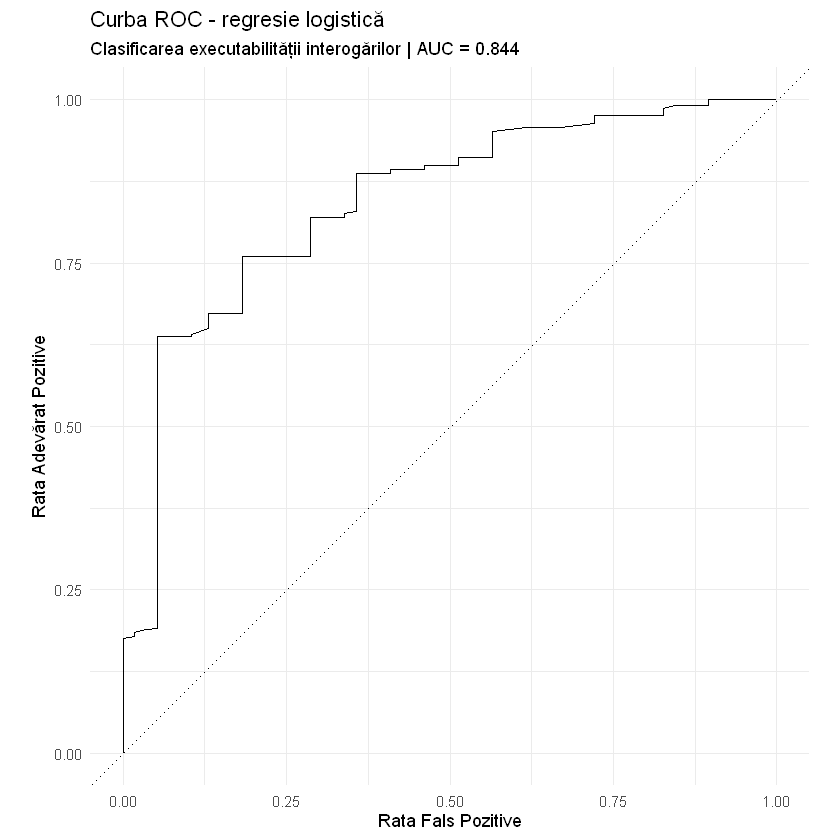

In [47]:
auc_value <- logreg_auc$.estimate

logreg_roc_plot <- autoplot(logreg_roc_curve) +
  labs(
    title = "Curba ROC - regresie logistică",
    subtitle = paste0(
      "Clasificarea executabilității interogărilor | AUC = ",
      round(auc_value, 3)
    ),
    x = "Rata Fals Pozitive",
    y = "Rata Adevărat Pozitive"
  ) +
  theme_minimal()

logreg_roc_plot

Curba se află vizibil deasupra diagonalei punctate, ceea ce indică faptul că modelul are o capacitate de clasificare mai bună decât o clasificare aleatorie. Cu cât curba este mai apropiată de colțul din stânga-sus, cu atât modelul reușește să obțină o rată mare de identificare corectă a execuțiilor reușite, menținând în același timp o rată redusă de clasificări fals pozitive.

In [48]:
ggsave(
  filename = file.path(figures_dir, "03_ml_logreg_roc_curve.png"),
  plot = logreg_roc_plot,
  width = 7,
  height = 5,
  dpi = 300
)

## Importanța coeficienților

In [63]:
logreg_coefficients_true <- final_logreg_fit %>%
  extract_fit_parsnip() %>%
  tidy(penalty = best_logreg$penalty) %>%
  filter(term != "(Intercept)") %>%
  mutate(
    # coeficienții glmnet sunt interpretați pentru clasa FALSE;
    # pentru success = TRUE inversăm semnul
    estimate_true = -estimate,
    importance = abs(estimate_true),
    direction = if_else(
      estimate_true > 0,
      "Crește probabilitatea de succes",
      "Scade probabilitatea de succes"
    )
  ) %>%
  arrange(desc(importance))

logreg_coefficients_true

term,estimate,penalty,estimate_true,importance,direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
n_aggregate_types,-1.077933257,0.01019609,1.077933257,1.077933257,Crește probabilitatea de succes
architecture_distributed,0.632723947,0.01019609,-0.632723947,0.632723947,Scade probabilitatea de succes
has_window_yes,-0.567733177,0.01019609,0.567733177,0.567733177,Crește probabilitatea de succes
has_subqueries_yes,0.478996356,0.01019609,-0.478996356,0.478996356,Scade probabilitatea de succes
has_except_yes,-0.272032874,0.01019609,0.272032874,0.272032874,Crește probabilitatea de succes
has_rollup_yes,0.221749897,0.01019609,-0.221749897,0.221749897,Scade probabilitatea de succes
has_left_join_yes,-0.145648774,0.01019609,0.145648774,0.145648774,Crește probabilitatea de succes
has_intersect_yes,-0.140108575,0.01019609,0.140108575,0.140108575,Crește probabilitatea de succes
has_grouping_yes,0.135568876,0.01019609,-0.135568876,0.135568876,Scade probabilitatea de succes


In [64]:
write_csv(
  logreg_coefficients_true,
  file.path(tables_dir, "03_ml_logreg_coefficients_success_true.csv")
)

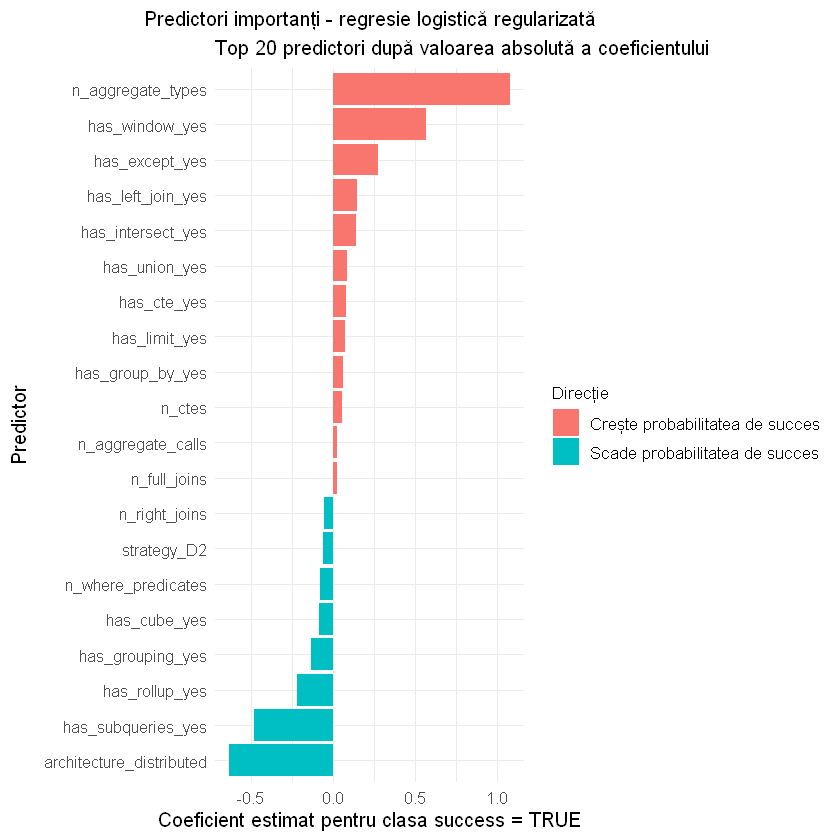

In [65]:
logreg_top20_true <- logreg_coefficients_true %>%
  slice_max(importance, n = 20)

logreg_coef_plot_true <- logreg_top20_true %>%
  mutate(
    term = fct_reorder(term, estimate_true)
  ) %>%
  ggplot(aes(x = estimate_true, y = term, fill = direction)) +
  geom_col() +
  labs(
    title = "Predictori importanți - regresie logistică regularizată",
    subtitle = "Top 20 predictori după valoarea absolută a coeficientului",
    x = "Coeficient estimat pentru clasa success = TRUE",
    y = "Predictor",
    fill = "Direcție"
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 12),
    plot.title = element_text(size = 12, hjust = 0.5),
    legend.title = element_text(size = 10),
    legend.text = element_text(size = 10)
  )

logreg_coef_plot_true

Importanța predictorilor în regresia logistică regularizată a fost analizată pe baza valorii absolute a coeficienților estimați. Graficul prezintă coeficienții exprimați pentru clasa `success = TRUE`, astfel încât valorile pozitive indică o asociere cu o probabilitate mai mare de execuție reușită, iar valorile negative indică o asociere cu o probabilitate mai mică de execuție reușită.

Rezultatele indică faptul că `n_aggregate_types`, `has_window_yes`, `has_except_yes`, `has_left_join_yes` și `has_intersect_yes` sunt printre predictorii asociați pozitiv cu probabilitatea de succes. În schimb, `architecture_distributed`, `has_subqueries_yes`, `has_rollup_yes`, `has_grouping_yes` și `has_cube_yes` au coeficienți negativi, sugerând o asociere cu o probabilitate mai redusă de execuție reușită.

Prin urmare, modelul logistic evidențiază faptul că atât arhitectura distribuită, cât și anumite caracteristici structurale ale interogărilor, în special subinterogările și operatorii OLAP de tip `ROLLUP`, `GROUPING` sau `CUBE`, contribuie la diferențierea execuțiilor reușite de cele eșuate.

Ce urmează e invera coeficienților de mai sus.

In [66]:
logreg_coefficients_false <- final_logreg_fit %>%
  extract_fit_parsnip() %>%
  tidy(penalty = best_logreg$penalty) %>%
  filter(term != "(Intercept)") %>%
  mutate(
    importance = abs(estimate),
    direction = if_else(
      estimate > 0,
      "Crește probabilitatea de eșec",
      "Scade probabilitatea de eșec"
    )
  ) %>%
  arrange(desc(importance))

logreg_coefficients_false

term,estimate,penalty,importance,direction
<chr>,<dbl>,<dbl>,<dbl>,<chr>
n_aggregate_types,-1.077933257,0.01019609,1.077933257,Scade probabilitatea de eșec
architecture_distributed,0.632723947,0.01019609,0.632723947,Crește probabilitatea de eșec
has_window_yes,-0.567733177,0.01019609,0.567733177,Scade probabilitatea de eșec
has_subqueries_yes,0.478996356,0.01019609,0.478996356,Crește probabilitatea de eșec
has_except_yes,-0.272032874,0.01019609,0.272032874,Scade probabilitatea de eșec
has_rollup_yes,0.221749897,0.01019609,0.221749897,Crește probabilitatea de eșec
has_left_join_yes,-0.145648774,0.01019609,0.145648774,Scade probabilitatea de eșec
has_intersect_yes,-0.140108575,0.01019609,0.140108575,Scade probabilitatea de eșec
has_grouping_yes,0.135568876,0.01019609,0.135568876,Crește probabilitatea de eșec


Ce urmează e invera coeficienților de mai sus.

In [67]:
write_csv(
  logreg_coefficients_false,
  file.path(tables_dir, "03_ml_logreg_coefficients_success_false.csv")
)

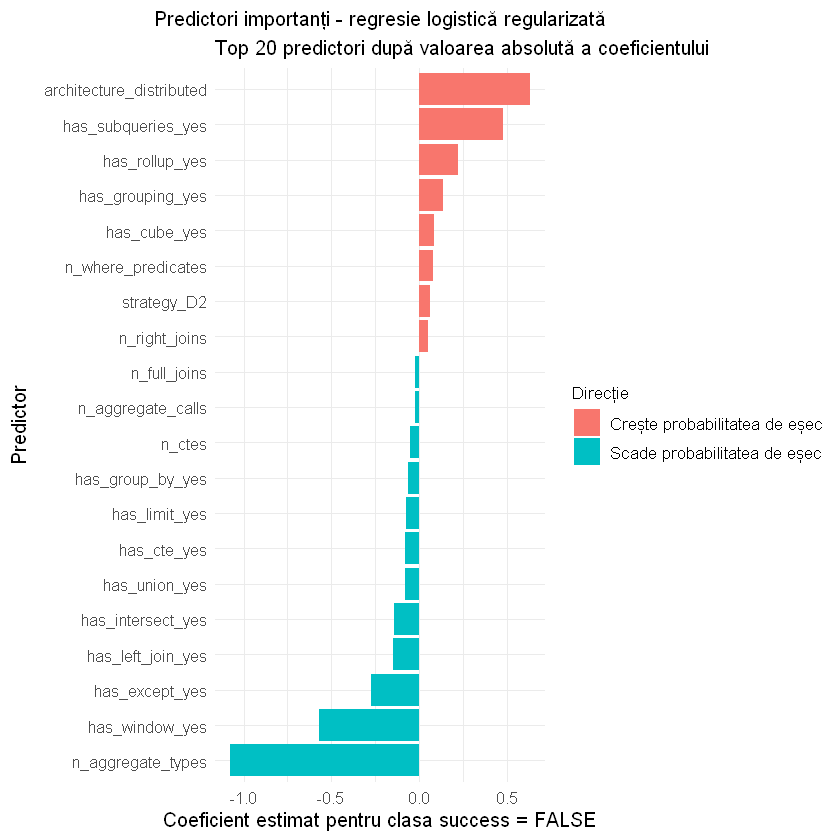

In [68]:
logreg_top20_false <- logreg_coefficients_false %>%
  slice_max(importance, n = 20)

logreg_coef_plot_false <- logreg_top20_false %>%
  mutate(
    term = fct_reorder(term, estimate)
  ) %>%
  ggplot(aes(x = estimate, y = term, fill = direction)) +
  geom_col() +
  labs(
    title = "Predictori importanți - regresie logistică regularizată",
    subtitle = "Top 20 predictori după valoarea absolută a coeficientului",
    x = "Coeficient estimat pentru clasa success = FALSE",
    y = "Predictor",
    fill = "Direcție"
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 12),
    plot.title = element_text(size = 12, hjust = 0.5),
    legend.title = element_text(size = 10),
    legend.text = element_text(size = 10)
  )

logreg_coef_plot_false

## b. Random Forest Classifier
Al doilea model utilizat pentru clasificarea executabilității este Random Forest, implementat prin motorul `ranger`. Spre deosebire de regresia logistică, Random Forest poate surprinde relații neliniare și interacțiuni între predictori, fiind potrivit pentru compararea performanței cu un model liniar regularizat.

Hiperparametrii optimizați sunt:

- `mtry`, numărul de predictori considerați la fiecare split;
- `min_n`, numărul minim de observații într-un nod terminal.

In [70]:
rf_class_spec <- rand_forest(
  mtry = tune(),
  trees = 800,
  min_n = tune()
) %>%
  set_engine("ranger") %>%
  set_mode("classification")

rf_class_spec

Random Forest Model Specification (classification)

Main Arguments:
  mtry = tune()
  trees = 800
  min_n = tune()

Computational engine: ranger 


In [71]:
rf_class_wf <- workflow() %>%
  add_recipe(classif_recipe) %>%
  add_model(rf_class_spec)

rf_class_wf

══ Workflow ════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: rand_forest()

── Preprocessor ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
3 Recipe Steps

• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Random Forest Model Specification (classification)

Main Arguments:
  mtry = tune()
  trees = 800
  min_n = tune()

Computational engine: ranger 


In [73]:
set.seed(123)

n_classif_predictors <- classif_train %>%
  select(-success, -query_id) %>%
  ncol()

rf_class_grid <- dials::grid_random(
  mtry(range = c(2, n_classif_predictors)),
  min_n(range = c(2, 40)),
  size = 100
)

rf_class_grid

mtry,min_n
<int>,<int>
32,28
16,6
15,7
4,17
15,25
26,33
27,22
28,12
6,37


In [74]:
set.seed(123)

rf_class_tuned <- tune_grid(
  rf_class_wf,
  resamples = classif_folds,
  grid = rf_class_grid,
  metrics = classif_metrics,
  control = ctrl_grid
)

Warning message:
"package 'ranger' was built under R version 4.4.3"
i Resample1: preprocessor 1/1

✓ Resample1: preprocessor 1/1

i Resample1: preprocessor 1/1, model 1/96

✓ Resample1: preprocessor 1/1, model 1/96

i Resample1: preprocessor 1/1, model 1/96 (extracts)

i Resample1: preprocessor 1/1, model 1/96 (predictions)

i Resample1: preprocessor 1/1, model 2/96

✓ Resample1: preprocessor 1/1, model 2/96

i Resample1: preprocessor 1/1, model 2/96 (extracts)

i Resample1: preprocessor 1/1, model 2/96 (predictions)

i Resample1: preprocessor 1/1, model 3/96

✓ Resample1: preprocessor 1/1, model 3/96

i Resample1: preprocessor 1/1, model 3/96 (extracts)

i Resample1: preprocessor 1/1, model 3/96 (predictions)

i Resample1: preprocessor 1/1, model 4/96

✓ Resample1: preprocessor 1/1, model 4/96

i Resample1: preprocessor 1/1, model 4/96 (extracts)

i Resample1: preprocessor 1/1, model 4/96 (predictions)

i Resample1: preprocessor 1/1, model 5/96

✓ Resample1: preprocessor 1/1, model 5/

In [75]:
rf_class_tuned_metrics <- rf_class_tuned %>%
  collect_metrics()

rf_class_tuned_metrics

mtry,min_n,.metric,.estimator,mean,n,std_err,.config
<int>,<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
32,28,accuracy,binary,0.9009860,5,0.019947137,Preprocessor1_Model01
32,28,bal_accuracy,binary,0.6891469,5,0.069029992,Preprocessor1_Model01
32,28,roc_auc,binary,0.8767248,5,0.021725085,Preprocessor1_Model01
32,28,sens,binary,0.9692703,5,0.025060039,Preprocessor1_Model01
32,28,spec,binary,0.4090235,5,0.152376858,Preprocessor1_Model01
16,6,accuracy,binary,0.9045490,5,0.019306434,Preprocessor1_Model02
16,6,bal_accuracy,binary,0.7027689,5,0.067979180,Preprocessor1_Model02
16,6,roc_auc,binary,0.8971712,5,0.017250834,Preprocessor1_Model02
16,6,sens,binary,0.9673008,5,0.023589364,Preprocessor1_Model02


In [76]:
write_csv(
  rf_class_tuned_metrics,
  file.path(tables_dir, "03_ml_rf_classification_tuning_metrics.csv")
)

saveRDS(
  rf_class_tuned,
  file.path(models_dir, "03_ml_rf_classification_tuned.rds")
)

In [77]:
best_rf_class <- rf_class_tuned %>%
  select_best(metric = "roc_auc")

best_rf_class

mtry,min_n,.config
<int>,<int>,<chr>
6,11,Preprocessor1_Model59


In [78]:
write_csv(
  best_rf_class,
  file.path(tables_dir, "03_ml_rf_classification_best_params.csv")
)

In [79]:
rf_class_imp_spec <- rf_class_spec %>%
  finalize_model(best_rf_class) %>%
  set_engine("ranger", importance = "permutation") %>%
  set_mode("classification")

rf_class_imp_spec

Random Forest Model Specification (classification)

Main Arguments:
  mtry = 6
  trees = 800
  min_n = 11

Engine-Specific Arguments:
  importance = permutation

Computational engine: ranger 


In [80]:
final_rf_class_wf <- workflow() %>%
  add_recipe(classif_recipe) %>%
  add_model(rf_class_imp_spec)

final_rf_class_wf

══ Workflow ════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: rand_forest()

── Preprocessor ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
3 Recipe Steps

• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Random Forest Model Specification (classification)

Main Arguments:
  mtry = 6
  trees = 800
  min_n = 11

Engine-Specific Arguments:
  importance = permutation

Computational engine: ranger 


In [81]:
set.seed(123)

final_rf_class_fit <- final_rf_class_wf %>%
  fit(data = classif_train)

final_rf_class_fit

══ Workflow [trained] ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: rand_forest()

── Preprocessor ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
3 Recipe Steps

• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Ranger result

Call:
 ranger::ranger(x = maybe_data_frame(x), y = y, mtry = min_cols(~6L,      x), num.trees = ~800, min.node.size = min_rows(~11L, x),      importance = ~"permutation", num.threads = 1, verbose = FALSE,      seed = sample.int(10^5, 1), probability = TRUE) 

Type:                             Probability estimation 
Number of trees:                  800 
Sample size:                      2610 
Number of independent variables:  4

In [82]:
saveRDS(
  final_rf_class_fit,
  file.path(models_dir, "03_ml_final_rf_classification.rds")
)

In [84]:
rf_class_test_predictions <- predict(final_rf_class_fit, classif_test, type = "prob") %>%
  bind_cols(
    predict(final_rf_class_fit, classif_test, type = "class")
  ) %>%
  bind_cols(
    classif_test %>% select(success, query_id)
  )

glimpse(rf_class_test_predictions)

Rows: 1,140
Columns: 5
$ .pred_TRUE  <dbl> 0.9983876, 0.9680221, 0.8466475, 0.9354274, 0.9974203, 0.9…
$ .pred_FALSE <dbl> 0.0016123694, 0.0319779272, 0.1533525116, 0.0645726393, 0.…
$ .pred_class <fct> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE…
$ success     <fct> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE…
$ query_id    <chr> "Q002", "Q003", "Q010", "Q011", "Q016", "Q019", "Q020", "Q…


In [85]:
write_csv(
  rf_class_test_predictions,
  file.path(tables_dir, "03_ml_rf_classification_test_predictions.csv")
)

In [86]:
rf_class_test_metrics <- bind_rows(
  accuracy(
    rf_class_test_predictions,
    truth = success,
    estimate = .pred_class
  ),
  bal_accuracy(
    rf_class_test_predictions,
    truth = success,
    estimate = .pred_class
  ),
  sens(
    rf_class_test_predictions,
    truth = success,
    estimate = .pred_class,
    event_level = "first"
  ),
  spec(
    rf_class_test_predictions,
    truth = success,
    estimate = .pred_class,
    event_level = "first"
  ),
  roc_auc(
    rf_class_test_predictions,
    truth = success,
    .pred_TRUE,
    event_level = "first"
  )
) %>%
  mutate(model = "Random Forest")

rf_class_test_metrics

.metric,.estimator,.estimate,model
<chr>,<chr>,<dbl>,<chr>
accuracy,binary,0.87894737,Random Forest
bal_accuracy,binary,0.50808059,Random Forest
sens,binary,0.97268293,Random Forest
spec,binary,0.04347826,Random Forest
roc_auc,binary,0.83241569,Random Forest


In [87]:
write_csv(
  rf_class_test_metrics,
  file.path(tables_dir, "03_ml_rf_classification_test_metrics.csv")
)

Modelul Random Forest obține pe setul de test o acuratețe de aproximativ 0.879, deci 88% dintre observații sunt clasificate corect. Totuși, această valoare trebuie interpretată cu prudență. Totuși, variabila țintă `success` este dezechilibrată și execuțiile reușite sunt majoritare.

Sensibilitatea are valoarea 0,973, ceea ce arată că modelul identifică foarte bine execuțiile reușite (`success = TRUE`). În schimb, specificitatea este foarte redusă, aproximativ 0.043. Aceasta indică faptul că modelul identifică slab execuțiile eșuate (`success = FALSE`), clasificând majoritatea acestora drept execuții reușite.
Balanced accuracy are valoarea 0.508, foarte apropiată de 0.5, ceea ce confirmă dezechilibrul dintre performanța pe clasa pozitivă și cea negativă. Deși modelul clasifică bine execuțiile reușite, capacitatea sa de a detecta eșecurile este limitată.

Valoarea ROC-AUC = 0.832 indică totuși o capacitate bună de separare probabilistică între execuțiile reușite și cele eșuate. Prin urmare, Random Forest reușește să atribuie scoruri probabilistice relevante, dar pragul implicit de clasificare nu este potrivit pentru identificarea clasei minoritare.

In [89]:
rf_class_conf_mat <- rf_class_test_predictions %>%
  conf_mat(
    truth = success,
    estimate = .pred_class
  )

rf_class_conf_mat_table <- rf_class_conf_mat %>%
  tidy()

write_csv(
  rf_class_conf_mat_table,
  file.path(tables_dir, "03_ml_rf_classification_confusion_matrix.csv")
)

rf_class_conf_mat

          Truth
Prediction TRUE FALSE
     TRUE   997   110
     FALSE   28     5

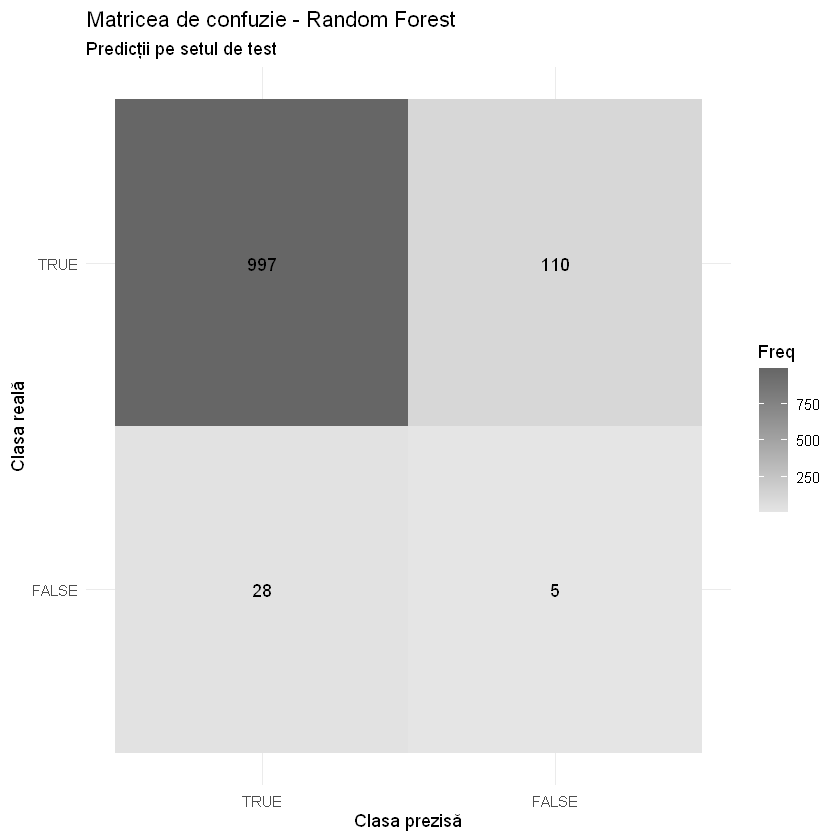

In [90]:
rf_class_conf_mat_plot <- autoplot(rf_class_conf_mat, type = "heatmap") +
  labs(
    title = "Matricea de confuzie - Random Forest",
    subtitle = "Predicții pe setul de test",
    x = "Clasa prezisă",
    y = "Clasa reală"
  ) +
  theme_minimal()

rf_class_conf_mat_plot

In [94]:
ggsave(
  filename = file.path(figures_dir, "03_ml_rf_classification_confusion_matrix.png"),
  plot = rf_class_conf_mat_plot,
  width = 7,
  height = 5,
  dpi = 300,
  bg = "white"
)

Matricea de confuzie confirmă comportamentul observat prin metricile de test. Modelul clasifică corect majoritatea execuțiilor reușite: din cele 1025 observații reale cu `success = TRUE`, 997 sunt prezise corect, iar 28 sunt clasificate greșit ca eșecuri.

În schimb, performanța pe clasa minoritară este foarte slabă. Din cele 115 observații reale cu `success = FALSE`, doar 5 sunt identificate corect ca eșecuri, în timp ce 110 sunt clasificate greșit ca execuții reușite.

Acest rezultat arată că modelul Random Forest favorizează puternic clasa majoritară `TRUE`. Deși are o capacitate ridicată de a recunoaște execuțiile reușite, modelul are dificultăți în identificarea execuțiilor eșuate la pragul implicit de clasificare. Prin urmare, matricea de confuzie susține interpretarea conform căreia acuratețea ridicată este influențată de dezechilibrul claselor și nu reflectă o performanță echilibrată pe ambele clase.

In [92]:
rf_class_roc_auc <- roc_auc(
  rf_class_test_predictions,
  truth = success,
  .pred_TRUE,
  event_level = "first"
)

rf_class_roc_auc

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
roc_auc,binary,0.8324157


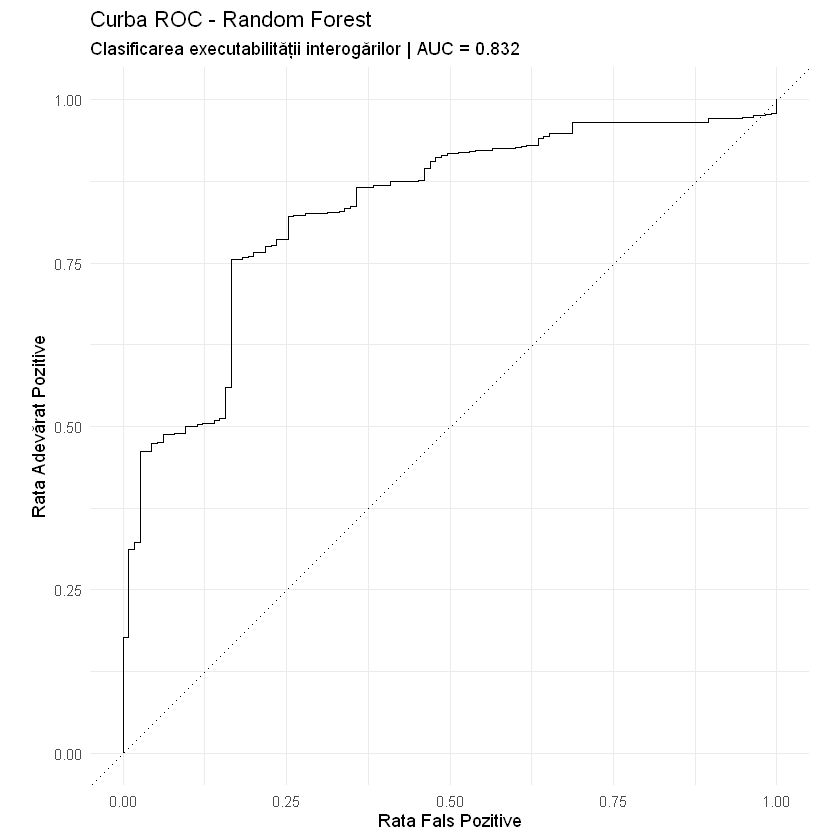

In [93]:
rf_class_roc_curve <- rf_class_test_predictions %>%
  roc_curve(
    truth = success,
    .pred_TRUE,
    event_level = "first"
  )

rf_auc_value <- rf_class_roc_auc$.estimate

rf_class_roc_plot <- autoplot(rf_class_roc_curve) +
  labs(
    title = "Curba ROC - Random Forest",
    subtitle = paste0(
      "Clasificarea executabilității interogărilor | AUC = ",
      round(rf_auc_value, 3)
    ),
    x = "Rata Fals Pozitive",
    y = "Rata Adevărat Pozitive"
  ) +
  theme_minimal()

rf_class_roc_plot

In [95]:
ggsave(
  filename = file.path(figures_dir, "03_ml_rf_classification_roc_curve.png"),
  plot = rf_class_roc_plot,
  width = 7,
  height = 5,
  dpi = 300,
  bg = "white"
)

## Importanța variabilelor

In [99]:
install.packages("vip")

Installing package into 'C:/Users/savas/AppData/Local/R/win-library/4.4'
(as 'lib' is unspecified)



package 'vip' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\savas\AppData\Local\Temp\RtmpSaaDWt\downloaded_packages


In [100]:
library(vip)

Warning message:
"package 'vip' was built under R version 4.4.3"

Attaching package: 'vip'


The following object is masked from 'package:utils':

    vi




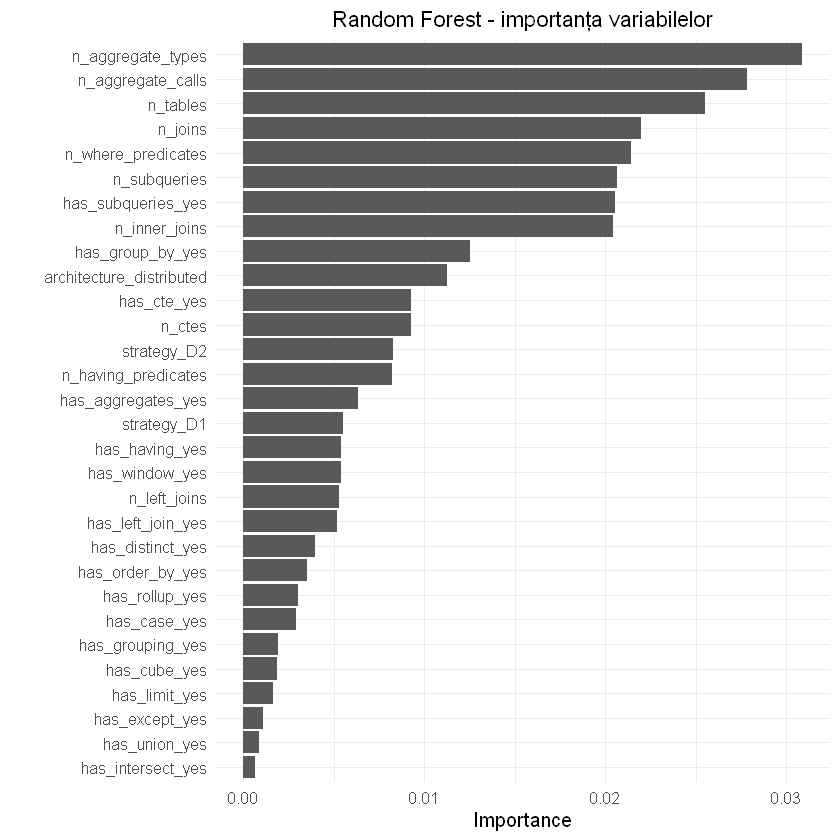

In [101]:
rf_class_varimp_plot <- final_rf_class_fit %>%
  extract_fit_parsnip() %>%
  vip(num_features = 30L) +
  ggtitle("Random Forest - importanța variabilelor") +
  theme_minimal() +
  theme(
    text = element_text(size = 12),
    plot.title = element_text(size = 13, hjust = 0.5)
  )

rf_class_varimp_plot

Importanța variabilelor în modelul Random Forest evidențiază faptul că predictorii cei mai relevanți pentru clasificarea executabilității sunt în principal caracteristici structurale ale interogărilor. Cele mai importante variabile sunt `n_aggregate_types`, `n_aggregate_calls`, `n_tables`, `n_joins`, `n_where_predicates`, `n_subqueries` și `has_subqueries_yes`. Acest rezultat sugerează că modelul acordă o importanță ridicată complexității interne a query-urilor, în special agregărilor, join-urilor, predicatelor și subinterogărilor.

Variabila `architecture_distributed` apare de asemenea între predictorii importanți, ceea ce indică faptul că arhitectura de execuție contribuie la clasificarea succesului sau eșecului interogărilor. Totuși, în comparație cu regresia logistică, Random Forest pune mai mult accent pe caracteristicile structurale ale interogărilor decât pe arhitectură ca predictor individual.


## Comparație - modele de clasificare

In [104]:
logreg_test_metrics <- logreg_test_metrics %>%
  mutate(model = "Logistic Regression")

rf_class_test_metrics <- rf_class_test_metrics %>%
  mutate(model = "Random Forest")

In [105]:
classification_models_metrics <- bind_rows(
  logreg_test_metrics,
  rf_class_test_metrics
) %>%
  select(model, .metric, .estimator, .estimate)

classification_models_metrics_wide <- classification_models_metrics %>%
  select(model, .metric, .estimate) %>%
  pivot_wider(
    names_from = .metric,
    values_from = .estimate
  )

classification_models_metrics_wide

model,accuracy,bal_accuracy,sens,spec,roc_auc
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Logistic Regression,0.9096491,0.5521739,1.0000000,0.10434783,0.8438897
Random Forest,0.8789474,0.5080806,0.9726829,0.04347826,0.8324157


In [106]:
write_csv(
  classification_models_metrics_wide,
  file.path(tables_dir, "03_ml_classification_models_comparison_wide.csv")
)

În urma comparației se observă cum regresia logistică are performanță ușor mai bună decât Random Forest pe setul de test. Aceasta obține valori mai ridicate pentru acuratețe, balanced accuracy, specificitate și ROC-AUC. Ambele modele identifică foarte bine execuțiile reușite (`success = TRUE`), dar au dificultăți în detectarea execuțiilor eșuate (`success = FALSE`), aspect evidențiat de valorile reduse ale specificității.

Prin urmare, regresia logistică este modelul mai bun pentru clasificarea executabilității în acest caz, iar Random Forest rămâne util mai ales pentru analiza importanței relative a variabilelor deoarece surprinde relații neliniare și interacțiuni dintre predictori. Spre deosebire de regresia logistică, unde importanța este interpretată prin coeficienți, Random Forest evaluează importanța predictorilor prin impactul acestora asupra performanței modelului. Astfel, modelul oferă o perspectivă complementară asupra variabilelor care contribuie la diferențierea execuțiilor reușite de cele eșuate.

In [107]:
rf_class_importance <- final_rf_class_fit %>%
  extract_fit_parsnip() %>%
  vip::vi() %>%
  rename(
    term = Variable,
    importance_rf = Importance
  ) %>%
  arrange(desc(importance_rf))

rf_class_importance

term,importance_rf
<chr>,<dbl>
n_aggregate_types,0.03088241572
n_aggregate_calls,0.02782030412
n_tables,0.02548321170
n_joins,0.02197604151
n_where_predicates,0.02142805300
n_subqueries,0.02064516302
has_subqueries_yes,0.02053128010
n_inner_joins,0.02040498257
has_group_by_yes,0.01253454005


In [108]:
write_csv(
  rf_class_importance,
  file.path(tables_dir, "03_ml_rf_classification_variable_importance.csv")
)

In [109]:
logreg_importance <- logreg_coefficients_true %>%
  select(term, importance) %>%
  rename(importance_logreg = importance)

logreg_importance

term,importance_logreg
<chr>,<dbl>
n_aggregate_types,1.077933257
architecture_distributed,0.632723947
has_window_yes,0.567733177
has_subqueries_yes,0.478996356
has_except_yes,0.272032874
has_rollup_yes,0.221749897
has_left_join_yes,0.145648774
has_intersect_yes,0.140108575
has_grouping_yes,0.135568876


In [110]:
variable_importance_comparison <- full_join(
  logreg_importance,
  rf_class_importance,
  by = "term"
) %>%
  replace_na(
    list(
      importance_logreg = 0,
      importance_rf = 0
    )
  ) %>%
  mutate(
    importance_logreg_norm = importance_logreg / max(importance_logreg),
    importance_rf_norm = importance_rf / max(importance_rf)
  )

variable_importance_comparison

term,importance_logreg,importance_rf,importance_logreg_norm,importance_rf_norm
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
n_aggregate_types,1.077933257,0.03088241572,1.000000000,1.0000000000
architecture_distributed,0.632723947,0.01124294209,0.586978779,0.3640564323
has_window_yes,0.567733177,0.00541646103,0.526686763,0.1753898102
has_subqueries_yes,0.478996356,0.02053128010,0.444365505,0.6648210517
has_except_yes,0.272032874,0.00111211175,0.252365230,0.0360111645
has_rollup_yes,0.221749897,0.00304446094,0.205717650,0.0985823444
has_left_join_yes,0.145648774,0.00521247485,0.135118546,0.1687845569
has_intersect_yes,0.140108575,0.00067542496,0.129978896,0.0218708590
has_grouping_yes,0.135568876,0.00193406151,0.125767412,0.0626266264


In [111]:
write_csv(
  variable_importance_comparison,
  file.path(tables_dir, "03_ml_classification_variable_importance_comparison.csv")
)

In [112]:
top_variables_comparison <- variable_importance_comparison %>%
  mutate(
    max_importance = pmax(importance_logreg_norm, importance_rf_norm)
  ) %>%
  slice_max(max_importance, n = 20) %>%
  select(term, importance_logreg_norm, importance_rf_norm) %>%
  pivot_longer(
    cols = c(importance_logreg_norm, importance_rf_norm),
    names_to = "model",
    values_to = "importance"
  ) %>%
  mutate(
    model = recode(
      model,
      importance_logreg_norm = "Logistic Regression",
      importance_rf_norm = "Random Forest"
    )
  )

top_variables_comparison

term,model,importance
<chr>,<chr>,<dbl>
n_aggregate_types,Logistic Regression,1.00000000
n_aggregate_types,Random Forest,1.00000000
n_aggregate_calls,Logistic Regression,0.01987540
n_aggregate_calls,Random Forest,0.90084611
n_tables,Logistic Regression,0.00000000
n_tables,Random Forest,0.82516899
n_joins,Logistic Regression,0.00000000
n_joins,Random Forest,0.71160371
n_where_predicates,Logistic Regression,0.07471832


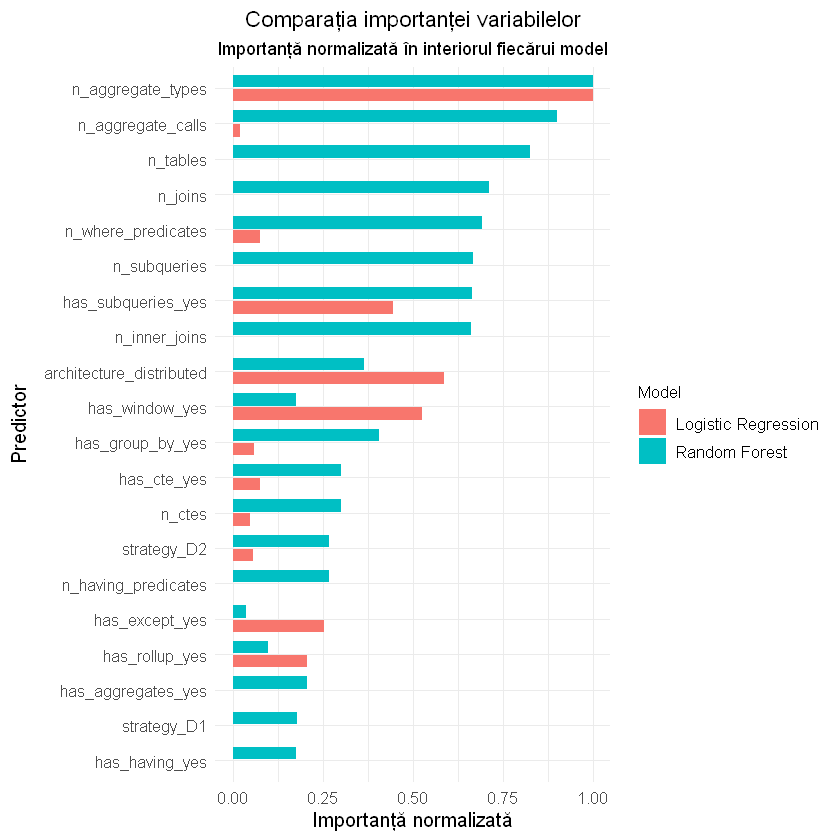

In [113]:
variable_importance_comparison_plot <- top_variables_comparison %>%
  mutate(
    term = fct_reorder(term, importance, .fun = max)
  ) %>%
  ggplot(aes(x = importance, y = term, fill = model)) +
  geom_col(
    position = position_dodge(width = 0.8),
    width = 0.7
  ) +
  labs(
    title = "Comparația importanței variabilelor",
    subtitle = "Importanță normalizată în interiorul fiecărui model",
    x = "Importanță normalizată",
    y = "Predictor",
    fill = "Model"
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 12),
    plot.title = element_text(size = 13, hjust = 0.5),
    plot.subtitle = element_text(size = 11, hjust = 0.5),
    legend.title = element_text(size = 10),
    legend.text = element_text(size = 10)
  )

variable_importance_comparison_plot

Graficul compară importanța relativă a predictorilor în cele două modele de clasificare, după normalizarea valorilor în interiorul fiecărui model. Trebuie avut în vedere faptul că regresia logistică și Random Forest calculează importanța variabilelor prin metode diferite, așadar graficul nu trebuie interpretat ca o comparație directă a valorilor absolute, ci ca o comparație a poziției relative a predictorilor în fiecare model.

Rezultatele arată că `n_aggregate_types` este un predictor important în ambele modele, ceea ce sugerează că diversitatea tipurilor de agregări are un rol relevant în explicarea executabilității interogărilor. Random Forest acordă o importanță ridicată mai multor caracteristici structurale ale query-urilor, precum `n_aggregate_calls`, `n_tables`, `n_joins`, `n_where_predicates`, `n_subqueries` și `has_subqueries_yes`. În schimb, regresia logistică evidențiază mai puternic variabile precum `architecture_distributed`, `has_window_yes`, `has_except_yes` și `has_rollup_yes`.

# II. Pregatirea datasetului pentru modelele de regresie

A doua direcție a analizei ML urmărește modelarea timpului de execuție al interogărilor finalizate cu succes. Spre deosebire de modelele de clasificare, care au analizat probabilitatea de succes sau eșec, modelele de regresie estimează durata execuției în funcție de arhitectură, factor de scalare, număr de workeri, strategie de distribuire și caracteristicile structurale ale interogării.

În această etapă sunt păstrate doar observațiile pentru care `success = TRUE`, deoarece timpul de execuție este relevant doar pentru interogările finalizate cu succes. Variabila țintă este `duration`, definită ca `log10(elapsed_sec)`, pentru a reduce asimetria distribuției timpilor de execuție și influența valorilor extreme.

In [7]:
# Dataset pentru regresie: target = duration = log10(elapsed_sec)

df_reg <- df %>%
  filter(success == TRUE) %>%
  rename(
    duration = log_elapsed_sec
  ) %>%
  select(
    duration,
    sf,
    workers,
    strategy,
    architecture,
    query_id,
    starts_with("n_"),
    starts_with("has_")
  ) %>%
  mutate(
    sf = factor(sf),
    workers = factor(workers),
    strategy = factor(strategy),
    architecture = factor(architecture)
  )

glimpse(df_reg)

Rows: 3,371
Columns: 39
$ duration            <dbl> 1.15121658, 0.84223469, 1.04178732, 1.10308500, 1.…
$ sf                  <fct> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10…
$ workers             <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ strategy            <fct> baseline, baseline, baseline, baseline, baseline, …
$ architecture        <fct> baseline, baseline, baseline, baseline, baseline, …
$ query_id            <chr> "Q001", "Q002", "Q003", "Q004", "Q005", "Q006", "Q…
$ n_tables            <dbl> 3, 3, 4, 6, 4, 4, 2, 3, 3, 3, 3, 4, 4, 4, 3, 4, 3,…
$ n_joins             <dbl> 2, 2, 3, 5, 3, 3, 1, 2, 3, 3, 2, 3, 2, 3, 2, 3, 4,…
$ n_inner_joins       <dbl> 2, 2, 3, 5, 2, 3, 1, 2, 3, 3, 2, 3, 2, 3, 2, 3, 4,…
$ n_left_joins        <dbl> 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_right_joins       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_full_joins        <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_cross_joins 

In [8]:
duration_summary <- df_reg %>%
  summarise(
    n = n(),
    min_duration = min(duration),
    q1_duration = quantile(duration, 0.25),
    median_duration = median(duration),
    mean_duration = mean(duration),
    q3_duration = quantile(duration, 0.75),
    max_duration = max(duration)
  )

duration_summary

write_csv(
  duration_summary,
  file.path(tables_dir, "03_ml_regression_duration_summary.csv")
)

n,min_duration,q1_duration,median_duration,mean_duration,q3_duration,max_duration
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3371,-0.7235382,0.7274599,1.283098,1.346451,1.953782,3.529385


Datasetul pentru modelele de regresie conține 3371 execuții finalizate cu succes. 

Valorile indică o variație ridicată a timpilor de execuție. Mediana este 1.283, ceea ce corespunde aproximativ unei durate de 19 secunde, iar media este 1.346, aproximativ 22 secunde pe scala retransformată. Primul quartil este 0.727, adică aproximativ 5.3 secunde, iar al treilea quartil este 1.954, adică aproximativ 90 de secunde. Valoarea maximă, 3.529, corespunde unei durate de aproximativ 3379 secunde, adică aproape 56 de minute.

Prin urmare, chiar și după filtrarea doar a execuțiilor reușite, timpul de execuție rămâne foarte variabil, ceea ce justifică utilizarea transformării logaritmice pentru modelele de regresie.

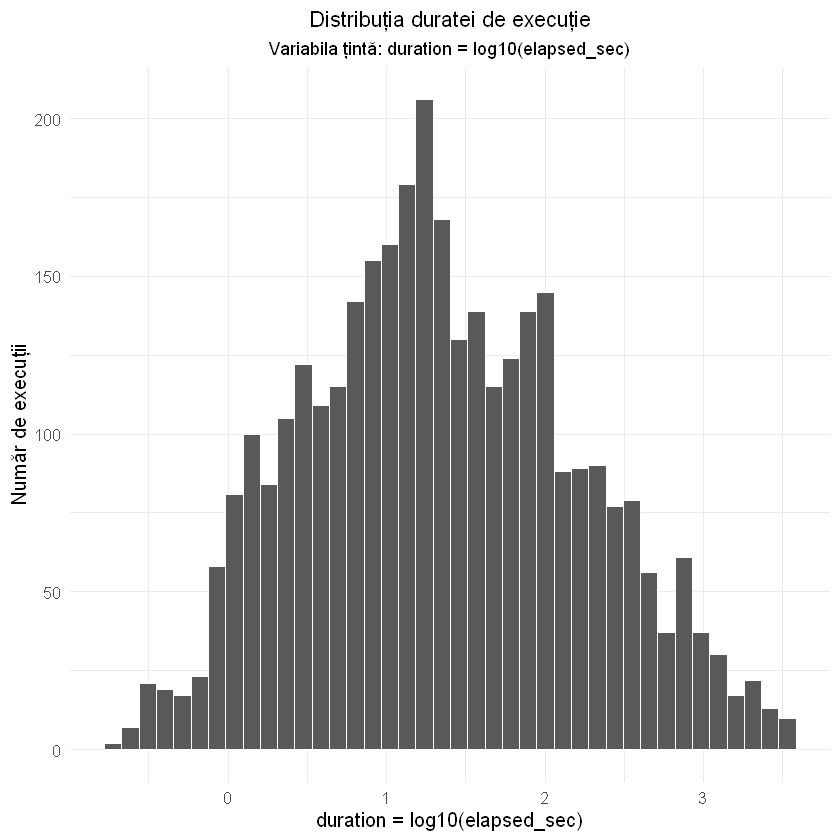

In [9]:
duration_hist_plot <- df_reg %>%
  ggplot(aes(x = duration)) +
  geom_histogram(
    bins = 40,
    color = "white"
  ) +
  labs(
    title = "Distribuția duratei de execuție",
    subtitle = "Variabila țintă: duration = log10(elapsed_sec)",
    x = "duration = log10(elapsed_sec)",
    y = "Număr de execuții"
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 12),
    plot.title = element_text(size = 13, hjust = 0.5),
    plot.subtitle = element_text(size = 11, hjust = 0.5)
  )

duration_hist_plot

In [10]:
ggsave(
  filename = file.path(figures_dir, "03_ml_regression_duration_histogram.png"),
  plot = duration_hist_plot,
  width = 7,
  height = 5,
  dpi = 300,
  bg = "white"
)

Histograma arată că durata logaritmată a execuțiilor reușite are o distribuție relativ concentrată în zona valorilor medii, cu cele mai multe observații între aproximativ 0.5 și 2 pe scala `log10(elapsed_sec)`. Distribuția nu este perfect simetrică, se observă o coadă spre dreapta, lucru ce indică prezența unor execuții reușite, dar considerabil mai lente. Acest comportament confirmă că, deși transformarea logaritmică reduce influența valorilor extreme, timpul de execuție rămâne variabil și justifică modelarea sa prin regresie.

## Împărțirea în seturi de train și test

In [11]:
query_reg_split_info <- df_reg %>%
  group_by(query_id) %>%
  summarise(
    median_duration = median(duration),
    n_obs = n(),
    .groups = "drop"
  ) %>%
  mutate(
    duration_bin = ntile(median_duration, 5),
    duration_bin = factor(duration_bin)
  )

query_reg_split_info %>%
  count(duration_bin)

duration_bin,n
<fct>,<int>
1,50
2,50
3,50
4,50
5,50


In [12]:
set.seed(123)

query_reg_split <- initial_split(
  query_reg_split_info,
  prop = 0.70,
  strata = duration_bin
)

train_reg_query_ids <- training(query_reg_split) %>%
  pull(query_id)

test_reg_query_ids <- testing(query_reg_split) %>%
  pull(query_id)

reg_train <- df_reg %>%
  filter(query_id %in% train_reg_query_ids)

reg_test <- df_reg %>%
  filter(query_id %in% test_reg_query_ids)

dim(reg_train)
dim(reg_test)

[1] 2383   39

[1] 988  39

Împărțirea datasetului pentru regresie a fost pregătită la nivel de `query_id`, nu la nivel de observație individuală. Pentru fiecare interogare a fost calculată durata mediană de execuție, iar apoi interogările au fost împărțite în 5 grupe egale (`duration_bin`) folosind `ntile()`. 

Setul de date a fost împărțit în train și test folosind proporția 70% / 30%, cu stratificare după `duration_bin`. După split, au fost extrase listele de `query_id` pentru train și test, iar datasetul complet a fost filtrat pe baza acestora. Astfel, toate execuțiile unei interogări apar fie în train, fie în test, evitând apariția aceluiași query în ambele seturi.

În urma împărțirii, setul de antrenare conține 2383 observații și 39 de coloane, iar setul de test conține 988 observații și 39 de coloane. Proporția nu este exact 70/30 la nivel de observații, deoarece split-ul a fost realizat la nivel de `query_id`, iar fiecare interogare poate avea un număr diferit de execuții reușite.

In [13]:
reg_split_distribution <- bind_rows(
  reg_train %>%
    summarise(
      dataset = "train",
      n = n(),
      min_duration = min(duration),
      median_duration = median(duration),
      mean_duration = mean(duration),
      max_duration = max(duration)
    ),
  reg_test %>%
    summarise(
      dataset = "test",
      n = n(),
      min_duration = min(duration),
      median_duration = median(duration),
      mean_duration = mean(duration),
      max_duration = max(duration)
    )
)

reg_split_distribution

dataset,n,min_duration,median_duration,mean_duration,max_duration
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
train,2383,-0.7235382,1.275588,1.353193,3.529385
test,988,-0.5670307,1.289765,1.330190,3.511239


In [14]:
write_csv(
  reg_split_distribution,
  file.path(tables_dir, "03_ml_regression_train_test_distribution.csv")
)

## Folduri pentru validare încrucișată

In [15]:
set.seed(123)

reg_folds <- vfold_cv(
  reg_train,
  v = 5,
  strata = duration
)

## Crearea rețetei
Rețeta include următorii pași:
- variabila `duration` este tratată ca variabilă țintă
- `query_id` este tratat ca identificator
- variabilele categoriale sunt transformate în variabile dummy
- predictorii fără variație sunt eliminați
- variabilele numerice sunt standardizate pentru a fi comparabile ca scală

In [16]:
reg_recipe <- recipe(duration ~ ., data = reg_train) %>%
  update_role(query_id, new_role = "id") %>%
  step_dummy(all_nominal_predictors()) %>%
  step_zv(all_predictors()) %>%
  step_normalize(all_numeric_predictors())

reg_recipe



── Recipe ──────────────────────────────────────────────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:    1
predictor: 37
id:         1



── Operations 

• Dummy variables from: all_nominal_predictors()

• Zero variance filter on: all_predictors()

• Centering and scaling for: all_numeric_predictors()



## A. Regresia liniară

Primul model utilizat pentru estimarea timpului de execuție este regresia liniară. Acest model este folosit pentru a observa relația dintre durata logaritmată a execuției și predictorii experimentali sau structurali ai interogărilor.

In [19]:
# Metricile pentru modelul de regresie liniară

reg_metrics <- metric_set(
  rmse,
  rsq,
  mae
)

In [20]:
linreg_spec <- linear_reg() %>%
  set_engine("lm") %>%
  set_mode("regression")

linreg_spec

Linear Regression Model Specification (regression)

Computational engine: lm 


In [21]:
linreg_wf <- workflow() %>%
  add_recipe(reg_recipe) %>%
  add_model(linreg_spec)

linreg_wf

══ Workflow ════════════════════════════════════════════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: linear_reg()

── Preprocessor ────────────────────────────────────────────────────────────────────────────────────────────────────────
3 Recipe Steps

• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────────────────────────────────────────────
Linear Regression Model Specification (regression)

Computational engine: lm 


In [ ]:
# Evaluarea prin validare încrucișată
ctrl_resamples <- control_resamples(
  save_pred = TRUE,
  verbose = TRUE
)

set.seed(123)

linreg_resamples <- fit_resamples(
  linreg_wf,
  resamples = reg_folds,
  metrics = reg_metrics,
  control = ctrl_resamples
)

linreg_resamples

In [23]:
exists("linreg_resamples")

[1] TRUE

In [25]:
# Colectarea metricelor
linreg_cv_metrics <- linreg_resamples %>%
  collect_metrics() %>%
  mutate(model = "Linear Regression")

linreg_cv_metrics

.metric,.estimator,mean,n,std_err,.config,model
<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<chr>
mae,standard,0.4327317,5,0.01003025,Preprocessor1_Model1,Linear Regression
rmse,standard,0.5605237,5,0.01318663,Preprocessor1_Model1,Linear Regression
rsq,standard,0.5760242,5,0.01563485,Preprocessor1_Model1,Linear Regression


In [26]:
write_csv(
  linreg_cv_metrics,
  file.path(tables_dir, "03_ml_linreg_regression_cv_metrics.csv")
)

Rezultatele obținute prin validare încrucișată arată că regresia liniară are o capacitate medie de a estima durata de execuție. Modelul explică aproximativ 57.6% din variația timpilor de execcuție la scală locaritmică. Totuși, valorile RMSE și MAE arată că există încă diferențe între duratele estimate și cele reale.

In [28]:
# Antrenarea modelului pe setul de train

final_linreg_fit <- linreg_wf %>%
  fit(data = reg_train)

final_linreg_fit

══ Workflow [trained] ══════════════════════════════════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: linear_reg()

── Preprocessor ────────────────────────────────────────────────────────────────────────────────────────────────────────
3 Recipe Steps

• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────────────────────────────────────────────

Call:
stats::lm(formula = ..y ~ ., data = data)

Coefficients:
             (Intercept)                  n_tables                   n_joins  
                1.353193                  0.001338                  0.695568  
           n_inner_joins              n_left_joins             n_right_joins  
               -0.580016                  0.198174                  0.086868  
            n_full_joins             n_cross_joins              n_subqueries  
               -0.112099                        NA                 -0.197

In [29]:
saveRDS(
  final_linreg_fit,
  file.path(models_dir, "03_ml_final_linreg_regression.rds")
)

In [30]:
# Predicții pe setul de test
linreg_test_predictions <- predict(final_linreg_fit, reg_test) %>%
  bind_cols(
    reg_test %>%
      select(duration, query_id)
  )

glimpse(linreg_test_predictions)

Warning message in predict.lm(object = object$fit, newdata = new_data, type = "response", :
"prediction from rank-deficient fit; consider predict(., rankdeficient="NA")"


Rows: 988
Columns: 3
$ .pred    <dbl> 1.0260189, 0.8369670, 1.0993631, 1.0699094, 0.9543477, 0.9075…
$ duration <dbl> 1.1512166, 0.8422347, 1.1030850, 1.4632059, 0.1510633, 0.4493…
$ query_id <chr> "Q001", "Q002", "Q004", "Q005", "Q007", "Q009", "Q019", "Q022…


In [31]:
# Metrici pe setul de test
linreg_test_metrics <- linreg_test_predictions %>%
  reg_metrics(
    truth = duration,
    estimate = .pred
  ) %>%
  mutate(model = "Linear Regression")

linreg_test_metrics

.metric,.estimator,.estimate,model
<chr>,<chr>,<dbl>,<chr>
rmse,standard,0.6183846,Linear Regression
rsq,standard,0.4824763,Linear Regression
mae,standard,0.4698590,Linear Regression


Pe setul de test, regresia liniară explică aproximativ 48.2% din variația duratei logaritmate de execuție (`R² = 0.482`). Performanța este mai slabă decât în validarea încrucișată, ceea ce sugerează o capacitate de generalizare moderată.

Valorile erorilor (`RMSE = 0.619`, `MAE = 0.461`) indică faptul că modelul surprinde tendința generală a timpilor de execuție, dar estimările individuale pot avea abateri importante. Prin urmare, regresia liniară nu explică complet variația duratelor de execuție.

In [32]:
write_csv(
  linreg_test_metrics,
  file.path(tables_dir, "03_ml_linreg_regression_test_metrics.csv")
)

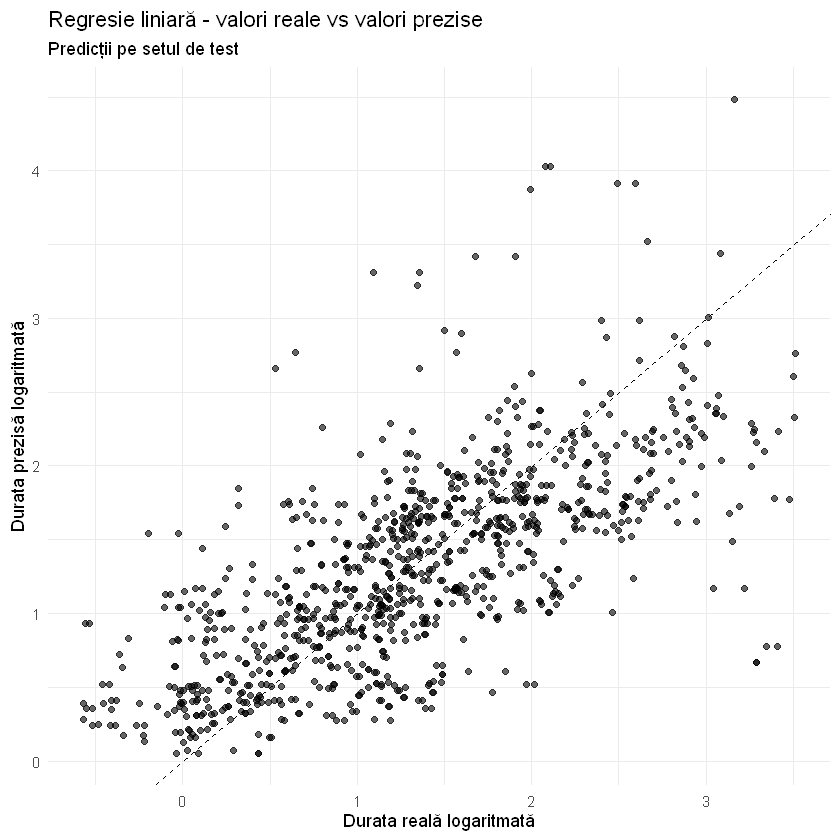

In [33]:
linreg_pred_plot <- linreg_test_predictions %>%
  ggplot(aes(x = duration, y = .pred)) +
  geom_point(alpha = 0.6) +
  geom_abline(
    intercept = 0,
    slope = 1,
    linetype = "dashed"
  ) +
  labs(
    title = "Regresie liniară - valori reale vs valori prezise",
    subtitle = "Predicții pe setul de test",
    x = "Durata reală logaritmată",
    y = "Durata prezisă logaritmată"
  ) +
  theme_minimal()

linreg_pred_plot

Graficul arată că există o relație pozitivă între duratele reale și cele prezise, ceea ce indică faptul că regresia liniară surprinde parțial tendința generală a timpilor de execuție. Totuși, dispersia punctelor față de linia diagonală este destul de mare, ceea ce arată că predicțiile individuale au abateri importante față de valorile reale.

Acest comportament se aliniază cu valoarea moderată a lui `R²` pe setul de test și sugerează că relația dintre predictori și durata de execuție nu este complet liniară. Prin urmare, regresia liniară oferă un model de referință interpretabil, dar are limitări clare în estimarea precisă a timpilor de execuție.

## Importanța coeficienților modelului

In [34]:
linreg_coefficients <- final_linreg_fit %>%
  extract_fit_parsnip() %>%
  tidy() %>%
  filter(term != "(Intercept)") %>%
  filter(!is.na(estimate)) %>%
  mutate(
    abs_estimate = abs(estimate),
    direction = if_else(
      estimate > 0,
      "Crește durata estimată",
      "Scade durata estimată"
    )
  ) %>%
  arrange(desc(abs_estimate))

linreg_coefficients

term,estimate,std.error,statistic,p.value,abs_estimate,direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
n_joins,0.695568017,0.16495878,4.21661709,0.00002573867945123635252169247422671105596236884593963623046875000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000,0.695568017,Crește durata estimată
sf_X100,0.591996410,0.01312823,45.09338033,0.00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001962429,0.591996410,Crește durata estimată
n_inner_joins,-0.580015836,0.16000137,-3.62506791,0.00029502665011033090206038487224304844858124852180480957031250000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000,0.580015836,Scade durata estimată
sf_X50,0.307226851,0.01313881,23.38315437,0.00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000068788315479911555025416269870675023412331938743591308593750000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000,0.307226851,Crește durata estimată
workers_X2,-0.275426944,0.01629422,-16.90335309,0.00000000000000000000000000000000000000000000000000000000000140011584441401410981720143666962030692957341670989990234375000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000,0.275426944,Scade durata estimată
workers_X5,-0.275070403,0.01629556,-16.88007891,0.00000000000000000000000000000000000000000000000000000000000199039479975502871175740970954848307883366942405700683593750000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000,0.275070403,Scade durata estimată
has_left_join_yes,-0.250106843,0.02810162,-8.90008665,0.00000000000000000109011532629432687292216075380935080829658545553684234619140625000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000,0.250106843,Scade durata estimată
has_subqueries_yes,0.199658684,0.02237087,8.92494212,0.00000000000000000087754529488853765589392863510909137403359636664390563964843750000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000,0.199658684,Crește durata estimată
n_left_joins,0.198173599,0.06613602,2.99645473,0.00275997522511308357104353738975532905897125601768493652343750000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000,0.198173599,Crește durata estimată


In [35]:
write_csv(
  linreg_coefficients,
  file.path(tables_dir, "03_ml_linreg_regression_coefficients.csv")
)

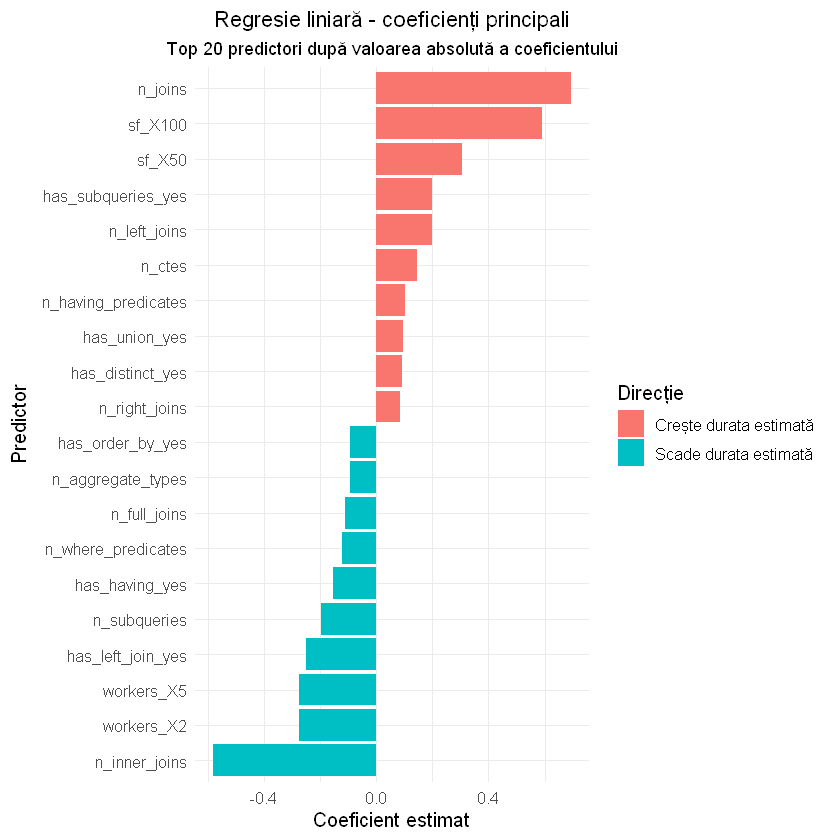

In [36]:
linreg_coef_plot <- linreg_coefficients %>%
  slice_max(abs_estimate, n = 20) %>%
  mutate(
    term = fct_reorder(term, estimate)
  ) %>%
  ggplot(aes(x = estimate, y = term, fill = direction)) +
  geom_col() +
  labs(
    title = "Regresie liniară - coeficienți principali",
    subtitle = "Top 20 predictori după valoarea absolută a coeficientului",
    x = "Coeficient estimat",
    y = "Predictor",
    fill = "Direcție"
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 12),
    plot.title = element_text(size = 13, hjust = 0.5),
    plot.subtitle = element_text(size = 11, hjust = 0.5)
  )

linreg_coef_plot

In [37]:
ggsave(
  filename = file.path(figures_dir, "03_ml_linreg_regression_coefficients.png"),
  plot = linreg_coef_plot,
  width = 8,
  height = 6,
  dpi = 300,
  bg = "white"
)

Graficul prezintă principalii coeficienți ai modelului de regresie liniară, calculați pentru variabila țintă `duration`.

Cei mai puternici predictori pozitivi sunt `n_joins`, `sf_X100` și `sf_X50`. Astfel, un număr mai mare de join-uri și volume de date mai mari sunt asociate cu timpi de execuție mai ridicați. De asemenea, prezența subinterogărilor, a join-urilor de tip left join, a CTE-urilor și a predicatelor `HAVING` contribuie la creșterea duratei estimate, ceea ce sugerează că structurile SQL mai complexe tind să încetinească execuția.

Coeficienții negativi apar pentru variabile precum `workers_X2` și `workers_X5`, ceea ce indică faptul că, în comparație cu categoria de referință, utilizarea workerilor este asociată cu o reducere a duratei estimate. Acest lucru susține ideea că execuția distribuită poate reduce timpul de rulare pentru o parte dintre interogări.

Un caz important este `n_inner_joins`, care apare cu un coeficient negativ, deși join-urile în general cresc durata. Acest rezultat nu trebuie interpretat izolat, deoarece modelul include simultan mai multe variabile corelate între ele, precum `n_joins`, `n_inner_joins`, `n_left_joins` și alți indicatori structurali.

În ansamblu, regresia liniară sugerează că durata execuției este influențată în principal de volumul datelor, numărul de join-uri și complexitatea structurală a interogărilor, în timp ce creșterea numărului de workeri este asociată cu reducerea duratei estimate.

## B. Random Forest Regressor

Al doilea model utilizat pentru estimarea duratei de execuție este Random Forest Regressor, implementat prin motorul `ranger`. Spre deosebire de regresia liniară, acest model poate surprinde relații neliniare și interacțiuni între predictori, fiind mai flexibil decît regresia liniară.

Hiperparametrii optimizați sunt:
- `mtry`, numărul de predictori considerați la fiecare split;
- `min_n`, numărul minim de observații într-un nod terminal.

In [38]:
rf_reg_spec <- rand_forest(
  mtry = tune(),
  trees = 800,
  min_n = tune()
) %>%
  set_engine("ranger") %>%
  set_mode("regression")

rf_reg_spec

Random Forest Model Specification (regression)

Main Arguments:
  mtry = tune()
  trees = 800
  min_n = tune()

Computational engine: ranger 


In [39]:
rf_reg_wf <- workflow() %>%
  add_recipe(reg_recipe) %>%
  add_model(rf_reg_spec)

rf_reg_wf

══ Workflow ════════════════════════════════════════════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: rand_forest()

── Preprocessor ────────────────────────────────────────────────────────────────────────────────────────────────────────
3 Recipe Steps

• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────────────────────────────────────────────
Random Forest Model Specification (regression)

Main Arguments:
  mtry = tune()
  trees = 800
  min_n = tune()

Computational engine: ranger 


In [40]:
# Grila de parametrii pentru tunning
set.seed(123)

n_reg_predictors <- reg_train %>%
  select(-duration, -query_id) %>%
  ncol()

rf_reg_grid <- dials::grid_random(
  mtry(range = c(2, n_reg_predictors)),
  min_n(range = c(2, 40)),
  size = 100
)

rf_reg_grid

mtry,min_n
<int>,<int>
32,28
16,6
15,7
4,17
15,25
26,33
27,22
28,12
6,37


In [43]:
set.seed(123)

rf_reg_tuned <- tune_grid(
  rf_reg_wf,
  resamples = reg_folds,
  grid = rf_reg_grid,
  metrics = reg_metrics,
  control = ctrl_grid
)

Warning message:
"package 'ranger' was built under R version 4.4.3"
i Fold1: preprocessor 1/1

✓ Fold1: preprocessor 1/1

i Fold1: preprocessor 1/1, model 1/96

✓ Fold1: preprocessor 1/1, model 1/96

i Fold1: preprocessor 1/1, model 1/96 (extracts)

i Fold1: preprocessor 1/1, model 1/96 (predictions)

i Fold1: preprocessor 1/1, model 2/96

✓ Fold1: preprocessor 1/1, model 2/96

i Fold1: preprocessor 1/1, model 2/96 (extracts)

i Fold1: preprocessor 1/1, model 2/96 (predictions)

i Fold1: preprocessor 1/1, model 3/96

✓ Fold1: preprocessor 1/1, model 3/96

i Fold1: preprocessor 1/1, model 3/96 (extracts)

i Fold1: preprocessor 1/1, model 3/96 (predictions)

i Fold1: preprocessor 1/1, model 4/96

✓ Fold1: preprocessor 1/1, model 4/96

i Fold1: preprocessor 1/1, model 4/96 (extracts)

i Fold1: preprocessor 1/1, model 4/96 (predictions)

i Fold1: preprocessor 1/1, model 5/96

✓ Fold1: preprocessor 1/1, model 5/96

i Fold1: preprocessor 1/1, model 5/96 (extracts)

i Fold1: preprocessor 1/1,

In [44]:
# Colectarea metricilor
rf_reg_tuned_metrics <- rf_reg_tuned %>%
  collect_metrics()

rf_reg_tuned_metrics

mtry,min_n,.metric,.estimator,mean,n,std_err,.config
<int>,<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
32,28,mae,standard,0.3530431,5,0.008637002,Preprocessor1_Model01
32,28,rmse,standard,0.4610872,5,0.015062070,Preprocessor1_Model01
32,28,rsq,standard,0.7166719,5,0.016245661,Preprocessor1_Model01
16,6,mae,standard,0.2988799,5,0.009909608,Preprocessor1_Model02
16,6,rmse,standard,0.4021768,5,0.017237550,Preprocessor1_Model02
16,6,rsq,standard,0.7876167,5,0.016618063,Preprocessor1_Model02
15,7,mae,standard,0.3039116,5,0.009611611,Preprocessor1_Model03
15,7,rmse,standard,0.4068173,5,0.016754517,Preprocessor1_Model03
15,7,rsq,standard,0.7839571,5,0.016168142,Preprocessor1_Model03


In [45]:
write_csv(
  rf_reg_tuned_metrics,
  file.path(tables_dir, "03_ml_rf_regression_tuning_metrics.csv")
)

In [46]:
# Alegerea celui mai bun model după RMSE
best_rf_reg <- rf_reg_tuned %>%
  select_best(metric = "rmse")

best_rf_reg

mtry,min_n,.config
<int>,<int>,<chr>
37,5,Preprocessor1_Model20


In [47]:
rf_reg_final_spec <- rf_reg_spec %>%
  finalize_model(best_rf_reg) %>%
  set_engine("ranger", importance = "permutation") %>%
  set_mode("regression")

rf_reg_final_spec

Random Forest Model Specification (regression)

Main Arguments:
  mtry = 37
  trees = 800
  min_n = 5

Engine-Specific Arguments:
  importance = permutation

Computational engine: ranger 


In [48]:
rf_reg_final_wf <- workflow() %>%
  add_recipe(reg_recipe) %>%
  add_model(rf_reg_final_spec)

rf_reg_final_wf

══ Workflow ════════════════════════════════════════════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: rand_forest()

── Preprocessor ────────────────────────────────────────────────────────────────────────────────────────────────────────
3 Recipe Steps

• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────────────────────────────────────────────
Random Forest Model Specification (regression)

Main Arguments:
  mtry = 37
  trees = 800
  min_n = 5

Engine-Specific Arguments:
  importance = permutation

Computational engine: ranger 


In [49]:
# Antrenarea finală a modelului
set.seed(123)

final_rf_reg_fit <- rf_reg_final_wf %>%
  fit(data = reg_train)

final_rf_reg_fit

══ Workflow [trained] ══════════════════════════════════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: rand_forest()

── Preprocessor ────────────────────────────────────────────────────────────────────────────────────────────────────────
3 Recipe Steps

• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────────────────────────────────────────────
Ranger result

Call:
 ranger::ranger(x = maybe_data_frame(x), y = y, mtry = min_cols(~37L,      x), num.trees = ~800, min.node.size = min_rows(~5L, x), importance = ~"permutation",      num.threads = 1, verbose = FALSE, seed = sample.int(10^5,          1)) 

Type:                             Regression 
Number of trees:                  800 
Sample size:                      2383 
Number of independent variables:  40 
Mtry:                             37 
Target node size:                 5 
Variable importance mode:         

In [50]:
saveRDS(
  final_rf_reg_fit,
  file.path(models_dir, "03_ml_final_rf_regression.rds")
)

In [51]:
# Predicții pe setul de test
rf_reg_test_predictions <- predict(final_rf_reg_fit, reg_test) %>%
  bind_cols(
    reg_test %>%
      select(duration, query_id)
  )

glimpse(rf_reg_test_predictions)

Rows: 988
Columns: 3
$ .pred    <dbl> 0.8663631, 0.6193673, 1.5853499, 1.3653431, 0.8550024, 1.2853…
$ duration <dbl> 1.1512166, 0.8422347, 1.1030850, 1.4632059, 0.1510633, 0.4493…
$ query_id <chr> "Q001", "Q002", "Q004", "Q005", "Q007", "Q009", "Q019", "Q022…


In [52]:
# Metricile pe setul de test
rf_reg_test_metrics <- rf_reg_test_predictions %>%
  reg_metrics(
    truth = duration,
    estimate = .pred
  ) %>%
  mutate(model = "Random Forest Regressor")

rf_reg_test_metrics

.metric,.estimator,.estimate,model
<chr>,<chr>,<dbl>,<chr>
rmse,standard,0.6097781,Random Forest Regressor
rsq,standard,0.5005468,Random Forest Regressor
mae,standard,0.4586302,Random Forest Regressor


In [53]:
write_csv(
  rf_reg_test_metrics,
  file.path(tables_dir, "03_ml_rf_regression_test_metrics.csv")
)

Pe setul de test, Random Forest Regressor explică aproximativ 50.1% din variația duratei logaritmate de execuție (`R² = 0.501`). Valoarea indică o capacitate predictivă moderată: modelul surprinde o parte importantă din variația timpilor, dar nu explică integral diferențele dintre execuții. Comparativ cu regresia liniară, Random Forest are rezultate ușor mai bune: RMSE este mai mic, MAE este puțin mai mic, iar R² este mai ridicat.

Totuși, diferența față de regresia liniară nu este foarte mare. Prin urmare, Random Forest aduce o îmbunătățire moderată, dar nu schimbă radical capacitatea de predicție a modelului asupra duratei de execuție.

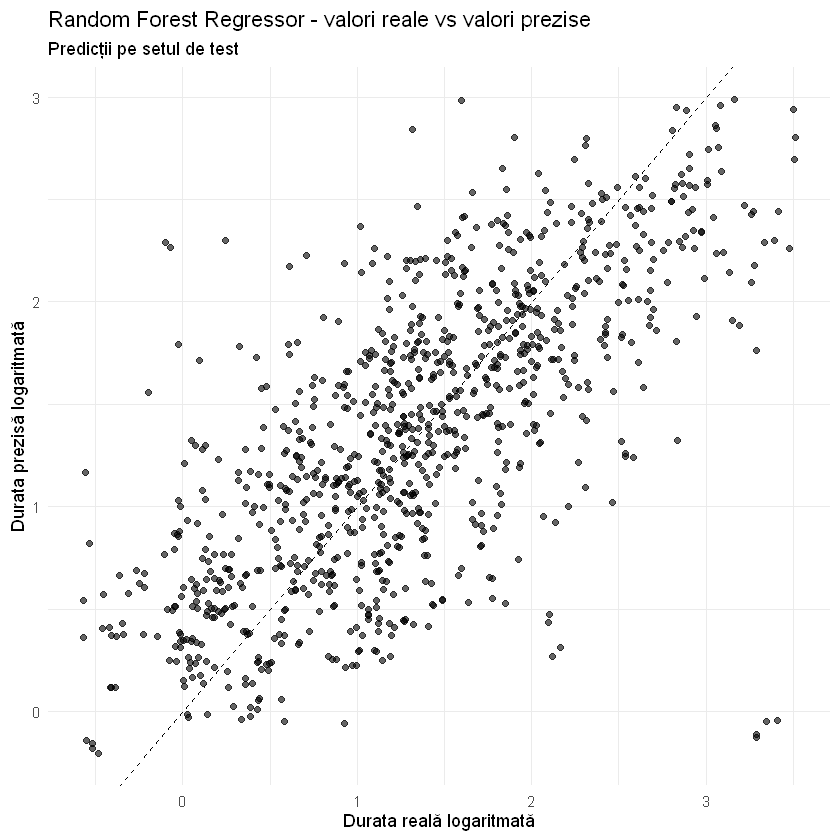

In [54]:
rf_reg_pred_plot <- rf_reg_test_predictions %>%
  ggplot(aes(x = duration, y = .pred)) +
  geom_point(alpha = 0.6) +
  geom_abline(
    intercept = 0,
    slope = 1,
    linetype = "dashed"
  ) +
  labs(
    title = "Random Forest Regressor - valori reale vs valori prezise",
    subtitle = "Predicții pe setul de test",
    x = "Durata reală logaritmată",
    y = "Durata prezisă logaritmată"
  ) +
  theme_minimal()

rf_reg_pred_plot

In [55]:
ggsave(
  filename = file.path(figures_dir, "03_ml_rf_regression_real_vs_predicted.png"),
  plot = rf_reg_pred_plot,
  width = 7,
  height = 5,
  dpi = 300,
  bg = "white"
)

Graficul arată o relație pozitivă între duratele reale și cele prezise, punctele având o orientare generală ascendentă. Comparativ cu regresia liniară, predicțiile par ușor mai apropiate de diagonala de referință, ceea ce este în acord cu valorile ușor mai bune ale metricilor pe setul de test.

Totuși, dispersia rămâne vizibilă, mai ales pentru duratele medii și mari, ceea ce arată că modelul nu estimează perfect timpii individuali de execuție. Random Forest surprinde mai bine tendința generală decât regresia liniară, dar variația timpilor de execuție rămâne dificil de explicat complet doar prin variabilele incluse.

## Importanța variabilelor

In [56]:
library(vip)

rf_reg_varimp <- final_rf_reg_fit %>%
  extract_fit_parsnip() %>%
  vip::vi() %>%
  arrange(desc(Importance))

rf_reg_varimp

Warning message:
"package 'vip' was built under R version 4.4.3"

Attaching package: 'vip'


The following object is masked from 'package:utils':

    vi




Variable,Importance
<chr>,<dbl>
sf_X100,0.584631018123
n_where_predicates,0.296017958012
n_inner_joins,0.175867567120
sf_X50,0.153734429462
n_aggregate_calls,0.145608332447
n_aggregate_types,0.135287640621
n_joins,0.112655595050
architecture_distributed,0.104428577671
n_tables,0.102145559249


In [57]:
write_csv(
  rf_reg_varimp,
  file.path(tables_dir, "03_ml_rf_regression_variable_importance.csv")
)

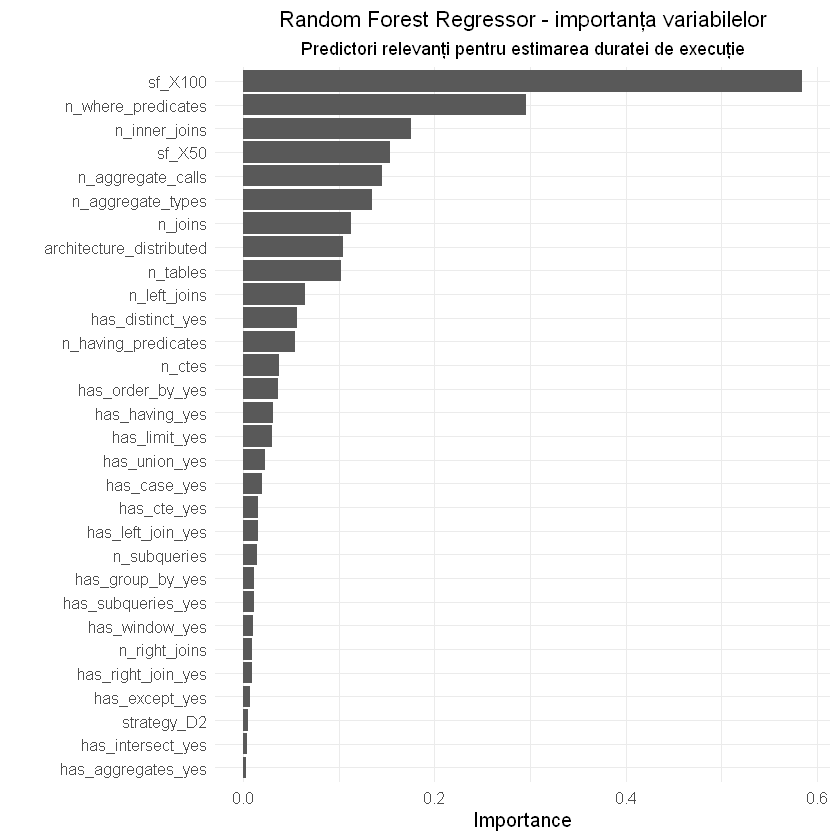

In [58]:
rf_reg_varimp_plot <- final_rf_reg_fit %>%
  extract_fit_parsnip() %>%
  vip(num_features = 30L) +
  labs(
    title = "Random Forest Regressor - importanța variabilelor",
    subtitle = "Predictori relevanți pentru estimarea duratei de execuție"
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 12),
    plot.title = element_text(size = 13, hjust = 0.5),
    plot.subtitle = element_text(size = 11, hjust = 0.5)
  )

rf_reg_varimp_plot

In [59]:
ggsave(
  filename = file.path(figures_dir, "03_ml_rf_regression_variable_importance.png"),
  plot = rf_reg_varimp_plot,
  width = 8,
  height = 6,
  dpi = 300,
  bg = "white"
)

Graficul arată că cel mai important predictor pentru estimarea duratei de execuție este `sf_X100`, ceea ce confirmă rolul major al volumului de date în creșterea timpilor de rulare. La scale factor mai mare, interogările procesează mai multe date, iar durata execuției devine semnificativ mai dificilă.

Următorii predictori importanți sunt `n_where_predicates`, `n_inner_joins`, `sf_X50`, `n_aggregate_calls`, `n_aggregate_types` și `n_joins`. Acest rezultat sugerează că timpul de execuție este influențat puternic de complexitatea structurală a interogărilor: numărul de predicate, join-uri și agregări contribuie la diferențierea query-urilor rapide de cele lente.

Variabila `architecture_distributed` apare de asemenea printre predictorii relevanți, ceea ce indică faptul că tipul arhitecturii contribuie la estimarea duratei de execuție.

Este important de menționat că Random Forest nu indică direcția efectului, ci doar importanța relativă a predictorilor. Prin urmare, graficul nu spune dacă o variabilă crește sau scade durata, ci cât de mult contribuie la capacitatea modelului de a estima timpul de execuție.

## Comparație - modele de regresie

In [62]:
regression_models_metrics_wide <- regression_models_metrics %>%
  select(model, .metric, .estimate) %>%
  pivot_wider(
    names_from = .metric,
    values_from = .estimate
  )

regression_models_metrics_wide

model,rmse,rsq,mae
<chr>,<dbl>,<dbl>,<dbl>
Linear Regression,0.6183846,0.4824763,0.4698590
Random Forest Regressor,0.6097781,0.5005468,0.4586302


In [63]:
write_csv(
  regression_models_metrics_wide,
  file.path(tables_dir, "03_ml_regression_models_comparison_wide.csv")
)

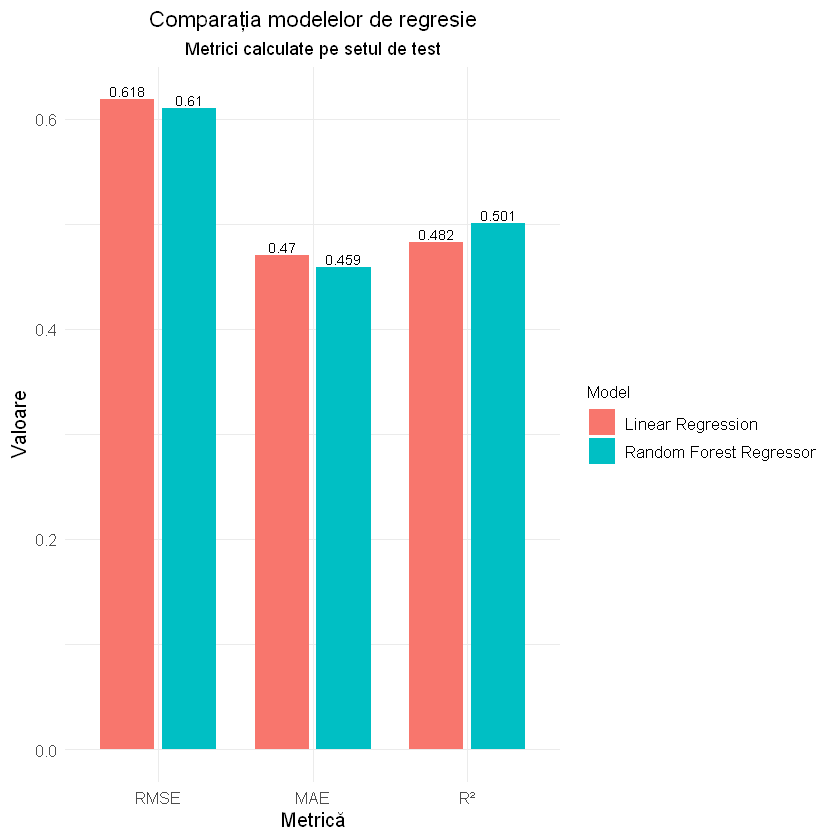

In [64]:
regression_metrics_plot <- regression_models_metrics %>%
  mutate(
    .metric = factor(
      .metric,
      levels = c("rmse", "mae", "rsq"),
      labels = c("RMSE", "MAE", "R²")
    )
  ) %>%
  ggplot(aes(x = .metric, y = .estimate, fill = model)) +
  geom_col(
    position = position_dodge(width = 0.8),
    width = 0.7
  ) +
  geom_text(
    aes(label = round(.estimate, 3)),
    position = position_dodge(width = 0.8),
    vjust = -0.3,
    size = 3
  ) +
  labs(
    title = "Comparația modelelor de regresie",
    subtitle = "Metrici calculate pe setul de test",
    x = "Metrică",
    y = "Valoare",
    fill = "Model"
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 12),
    plot.title = element_text(size = 13, hjust = 0.5),
    plot.subtitle = element_text(size = 11, hjust = 0.5),
    legend.title = element_text(size = 10),
    legend.text = element_text(size = 10)
  )

regression_metrics_plot

In [65]:
ggsave(
  filename = file.path(figures_dir, "03_ml_regression_models_comparison.png"),
  plot = regression_metrics_plot,
  width = 8,
  height = 5,
  dpi = 300,
  bg = "white"
)

Compararea modelelor de regresie pe setul de test arată că Random Forest Regressor are o performanță ușor mai bună decât regresia liniară, însă diferența dintre cele două modele nu este foarte mare. Acest rezultat sugerează că Random Forest surprinde mai bine unele relații neliniare sau interacțiuni dintre variabile, dar variația timpilor de execuție nu este explicată complet de predictorii incluși. 

Regresia liniară este utilă prin faptul că permite interpretarea direcției efectului predictorilor asupra duratei estimate de execuție, prin coeficienții modelului. În schimb, Random Forest evidențiază care variabile au cea mai mare contribuție la performanța predictivă a modelului. Putem considera cele două modele ca fiind complementare.

In [66]:
regression_variable_importance_comparison <- full_join(
  linreg_coefficients %>%
    select(term, estimate, abs_estimate) %>%
    rename(
      importance_linreg = abs_estimate,
      estimate_linreg = estimate
    ),
  
  rf_reg_varimp %>%
    rename(
      term = Variable,
      importance_rf = Importance
    ) %>%
    select(term, importance_rf),
  
  by = "term"
) %>%
  replace_na(
    list(
      importance_linreg = 0,
      importance_rf = 0
    )
  ) %>%
  mutate(
    importance_linreg_norm = importance_linreg / max(importance_linreg),
    importance_rf_norm = importance_rf / max(importance_rf),
    max_importance = pmax(importance_linreg_norm, importance_rf_norm)
  ) %>%
  arrange(desc(max_importance))

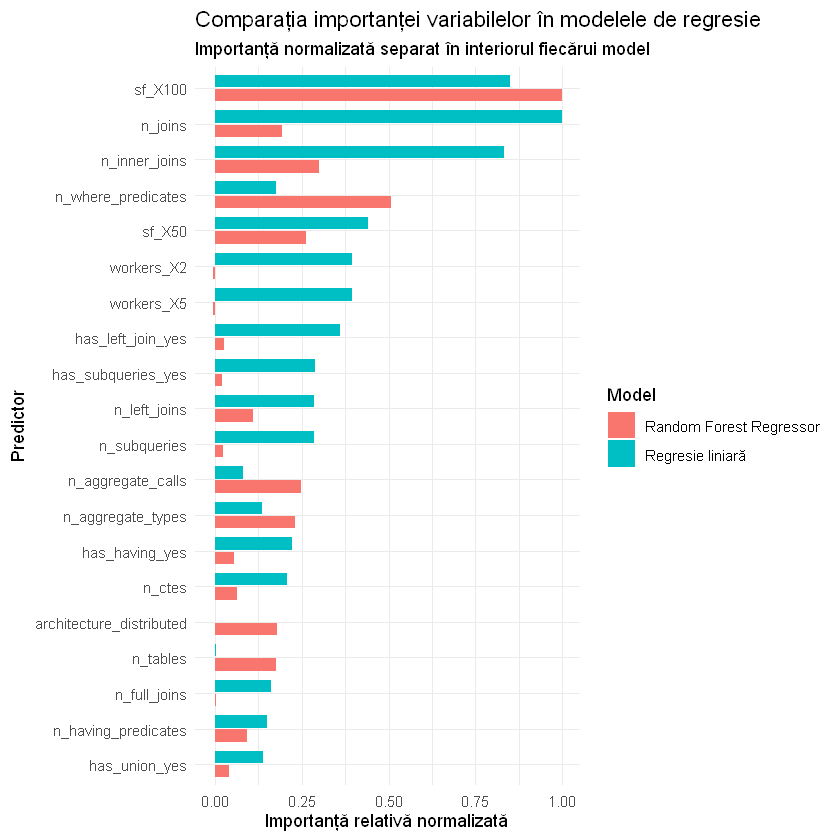

In [67]:
regression_varimp_comparison_plot <- regression_variable_importance_comparison %>%
  slice_max(max_importance, n = 20) %>%
  select(term, importance_linreg_norm, importance_rf_norm) %>%
  pivot_longer(
    cols = c(importance_linreg_norm, importance_rf_norm),
    names_to = "model",
    values_to = "importance"
  ) %>%
  mutate(
    model = recode(
      model,
      importance_linreg_norm = "Regresie liniară",
      importance_rf_norm = "Random Forest Regressor"
    ),
    term = fct_reorder(term, importance, .fun = max)
  ) %>%
  ggplot(aes(x = importance, y = term, fill = model)) +
  geom_col(
    position = position_dodge(width = 0.8),
    width = 0.7
  ) +
  labs(
    title = "Comparația importanței variabilelor în modelele de regresie",
    subtitle = "Importanță normalizată separat în interiorul fiecărui model",
    x = "Importanță relativă normalizată",
    y = "Predictor",
    fill = "Model"
  ) +
  theme_minimal()

regression_varimp_comparison_plot

In [68]:
ggsave(
  filename = file.path(figures_dir, "03_ml_regression_variable_importance_comparison.png"),
  plot = regression_varimp_comparison_plot,
  width = 9,
  height = 6,
  dpi = 300,
  bg = "white"
)

Graficul compară importanța relativă a variabilelor în cele două modele de regresie, după normalizarea importanțelor separat în interiorul fiecărui model. Prin urmare, valorile nu trebuie interpretate ca mărimi absolute comparabile direct, ci ca poziții relative ale predictorilor în fiecare model.

Ambele modele identifică `sf_X100` ca predictor foarte important, ceea ce confirmă că volumul datelor are un rol major în estimarea duratei de execuție. De asemenea, `n_joins`, `n_inner_joins`, `sf_X50` și variabilele legate de predicate, agregări și subinterogări apar printre predictorii relevanți, ceea ce arată că durata este influențată atât de dimensiunea datasetului, cât și de complexitatea structurală a query-urilor.

Regresia liniară pune mai mult accent pe predictori precum `n_joins`, `n_inner_joins`, `workers_X2`, `workers_X5`, `has_left_join_yes` și `has_subqueries_yes`, oferind și direcția efectului prin coeficienți. În schimb, Random Forest acordă importanță mai vizibilă unor variabile precum `n_where_predicates`, `n_aggregate_calls`, `n_aggregate_types`, `architecture_distributed` și `n_tables`, sugerând că acestea contribuie la predicție prin relații mai complexe sau interacțiuni între variabile.

În ansamblu, graficul confirmă că cele două modele sunt complementare: ambele susțin rolul scale factorului și al complexității interogării, dar evidențiază diferit importanța predictorilor în funcție de modul în care modelează relația cu durata de execuție.